In [ ]:
import subprocess, json
import pandas as pd
import numpy as np

# Dual-mode SQL: on Databricks (scheduled job / workspace notebook) use the native
# spark session; locally (VS Code) use the SQL-warehouse connector via the CLI token.
try:
    spark  # noqa: F821 - defined on Databricks
    def run_sql(query: str) -> pd.DataFrame:
        return spark.sql(query).toPandas()
    print("Connected (Databricks spark session).")
except NameError:
    from databricks import sql

    PROFILE   = "ShazebAsad"
    HOST      = "dbc-d10db17d-b6c4.cloud.databricks.com"
    HTTP_PATH = "/sql/1.0/warehouses/774b0b6877dcd0c3"

    def get_token() -> str:
        # fetched per query: the CLI caches and auto-refreshes, so this stays fresh
        return json.loads(
            subprocess.check_output(["databricks", "auth", "token", "--profile", PROFILE], text=True)
        )["access_token"]

    def run_sql(query: str) -> pd.DataFrame:
        with sql.connect(server_hostname=HOST, http_path=HTTP_PATH, access_token=get_token()) as conn:
            with conn.cursor() as cursor:
                cursor.execute(query)
                rows = cursor.fetchall()
                cols = [d[0] for d in cursor.description]
                return pd.DataFrame(rows, columns=cols)

    print("Connected (local SQL warehouse).")


In [ ]:
# On Databricks jobs the date comes from the 'intervention_date' job parameter
# (default = the real intervention). Locally, edit the fallback literal
# ('2025-10-06' = the validated placebo window).
try:
    dbutils.widgets.text('intervention_date', '2026-08-03')  # noqa: F821
    INTERVENTION_DATE = dbutils.widgets.get('intervention_date')  # noqa: F821
except NameError:
    INTERVENTION_DATE = '2026-08-03'
COVERAGE_DAYS     = 90            # forward window for the availability coverage metric

# all date ranges derived from the intervention date (must be a Monday)
_intervention = pd.Timestamp(INTERVENTION_DATE)
assert _intervention.dayofweek == 0, "INTERVENTION_DATE must be a Monday (week start)"
PRE_START  = (_intervention - pd.Timedelta(weeks=8)).strftime('%Y-%m-%d')  # first pre week
LAST_WEEK  = (_intervention + pd.Timedelta(weeks=7)).strftime('%Y-%m-%d')  # last post week
DATA_END   = (_intervention + pd.Timedelta(weeks=8)).strftime('%Y-%m-%d')  # exclusive

counts_query = f"""
WITH
cohort AS (
  -- LOCKED POOL: every gyg_status-active supplier as of 2026-08-04
  -- (production.supply_analytics.dst_supplier_pool, 17 countries, frozen).
  -- The pool IS the cohort - no further filters. Tours attach via LEFT JOIN:
  -- pool suppliers without a listed tour stay in the denominator.
  SELECT DISTINCT
    p.supplier_id,
    p.country_name,
    t.tour_id
  FROM production.supply_analytics.dst_supplier_pool p
  LEFT JOIN production.supply.int_tour_online_daily t
    ON  t.supplier_id = p.supplier_id
    AND t.date >= '{PRE_START}'
    AND t.date <  '{INTERVENTION_DATE}'
),
cohort_per_supplier AS (
  SELECT supplier_id, country_name,
    COUNT(DISTINCT tour_id) AS n_tours
  FROM cohort
  GROUP BY supplier_id, country_name
),
cohort_agg AS (
  SELECT country_name,
    COUNT(DISTINCT supplier_id) AS cohort_suppliers,
    COUNT(DISTINCT tour_id)     AS cohort_tours
  FROM cohort
  GROUP BY country_name
),
weeks AS (
  -- only weeks that have started: the current week carries partial data;
  -- future weeks are excluded rather than zero-filled as a fake collapse
  SELECT week_start FROM (
    SELECT EXPLODE(SEQUENCE(
      DATE '{PRE_START}', DATE '{LAST_WEEK}', INTERVAL 7 DAYS
    )) AS week_start
  ) WHERE week_start <= CURRENT_DATE()
),
supplier_weeks AS (
  SELECT cps.supplier_id, cps.country_name, cps.n_tours, w.week_start
  FROM cohort_per_supplier cps
  CROSS JOIN weeks w
),
online_supplier AS (
  SELECT
    DATE_TRUNC('WEEK', o.date) AS week_start,
    c.supplier_id,
    COUNT(DISTINCT o.tour_id)  AS tours_online
  FROM production.supply.int_tour_online_daily o
  JOIN cohort c ON o.tour_id = c.tour_id
  WHERE o.is_online = TRUE
    AND o.date >= '{PRE_START}'
    AND o.date <  '{DATA_END}'
  GROUP BY DATE_TRUNC('WEEK', o.date), c.supplier_id
),
-- forward coverage: for each snapshot week, look at the next {COVERAGE_DAYS} days only
avail_tour AS (
  SELECT
    w.week_start,
    c.supplier_id,
    c.country_name,
    a.tour_id,
    MAX(CASE WHEN a.vacancies > 0 THEN 1 ELSE 0 END)                AS has_avail,
    COUNT(DISTINCT CASE WHEN a.vacancies > 0 THEN a.travel_date END) AS days_with_slots
  FROM weeks w
  JOIN production.supply_analytics.fact_daily_availability_activity_history a
    ON  a.date        = w.week_start
    AND a.travel_date >= w.week_start
    AND a.travel_date <  w.week_start + INTERVAL {COVERAGE_DAYS} DAYS
  JOIN cohort c ON a.tour_id = c.tour_id
  GROUP BY w.week_start, c.supplier_id, c.country_name, a.tour_id
),
avail_supplier AS (
  SELECT
    week_start,
    supplier_id,
    country_name,
    COUNT(DISTINCT CASE WHEN has_avail = 1 THEN tour_id END) AS tours_with_avail,
    SUM(days_with_slots)                                      AS total_days_with_slots
  FROM avail_tour
  GROUP BY week_start, supplier_id, country_name
),
supplier_metrics AS (
  SELECT
    sw.week_start,
    sw.supplier_id,
    sw.country_name,
    COALESCE(os.tours_online, 0)                                  AS tours_online,
    CASE WHEN COALESCE(os.tours_online, 0) > 0 THEN 1 ELSE 0 END AS is_active,
    COALESCE(os.tours_online, 0) * 1.0 / NULLIF(sw.n_tours, 0)              AS pct_tours_online,
    -- share of the next {COVERAGE_DAYS} days with open slots, per active tour (NULL if no avail)
    avs.total_days_with_slots * 1.0
      / (NULLIF(avs.tours_with_avail, 0) * {COVERAGE_DAYS})       AS pct_days_with_avail_per_active_tour
  FROM supplier_weeks sw
  LEFT JOIN online_supplier os
    ON  os.week_start  = sw.week_start
    AND os.supplier_id = sw.supplier_id
  LEFT JOIN avail_supplier avs
    ON  avs.week_start  = sw.week_start
    AND avs.supplier_id = sw.supplier_id
)

SELECT
  sm.week_start,
  CASE WHEN sm.week_start < '{INTERVENTION_DATE}' THEN 'pre' ELSE 'post' END AS period,
  sm.country_name,
  ca.cohort_suppliers,
  ca.cohort_tours,
  SUM(sm.is_active)                             AS active_suppliers,
  SUM(sm.tours_online)                          AS active_tours,
  SUM(sm.is_active) * 1.0 / ca.cohort_suppliers AS pct_active_suppliers,
  AVG(sm.pct_tours_online)                      AS pct_tours_online_per_supplier,
  AVG(sm.pct_days_with_avail_per_active_tour)   AS pct_days_with_avail_per_active_tour
FROM supplier_metrics sm
JOIN cohort_agg ca ON sm.country_name = ca.country_name
GROUP BY sm.week_start, sm.country_name, ca.cohort_suppliers, ca.cohort_tours
ORDER BY sm.country_name, sm.week_start
"""

df = run_sql(counts_query)
df["week_start"]                          = pd.to_datetime(df["week_start"])
df["cohort_suppliers"]                    = df["cohort_suppliers"].astype(int)
df["cohort_tours"]                        = df["cohort_tours"].astype(int)
df["active_suppliers"]                    = df["active_suppliers"].astype(int)
df["active_tours"]                        = df["active_tours"].astype(int)
df["pct_active_suppliers"]                = df["pct_active_suppliers"].astype(float)
df["pct_tours_online_per_supplier"]       = df["pct_tours_online_per_supplier"].astype(float)
df["pct_days_with_avail_per_active_tour"] = df["pct_days_with_avail_per_active_tour"].astype(float)

print(f"Rows: {len(df)}")
df.head()

In [3]:
# Price metrics: per-adult travel-date prices over the next COVERAGE_DAYS days.
# Index: each tour vs its own pre-period average, in local currency (pre-period = 1.0
# by construction; the signal is the post-period deviation). black = base price
# (deliberate repricing), effective = red (what customers pay, catches discount
# withdrawal too). Tour indices winsorised to [0.5, 2.0] so a handful of glitchy
# tours can't distort the supplier average. Avg price levels converted to EUR at
# each snapshot week's rate.

price_query = f"""
WITH
cohort AS (
  -- LOCKED POOL: every gyg_status-active supplier as of 2026-08-04
  -- (production.supply_analytics.dst_supplier_pool, 17 countries, frozen).
  -- The pool IS the cohort - no further filters. Tours attach via LEFT JOIN:
  -- pool suppliers without a listed tour stay in the denominator.
  SELECT DISTINCT
    p.supplier_id,
    p.country_name,
    t.tour_id
  FROM production.supply_analytics.dst_supplier_pool p
  LEFT JOIN production.supply.int_tour_online_daily t
    ON  t.supplier_id = p.supplier_id
    AND t.date >= '{PRE_START}'
    AND t.date <  '{INTERVENTION_DATE}'
),
weeks AS (
  -- only weeks that have started: the current week carries partial data;
  -- future weeks are excluded rather than zero-filled as a fake collapse
  SELECT week_start FROM (
    SELECT EXPLODE(SEQUENCE(
      DATE '{PRE_START}', DATE '{LAST_WEEK}', INTERVAL 7 DAYS
    )) AS week_start
  ) WHERE week_start <= CURRENT_DATE()
),
-- units of currency per 1 EUR, daily
fx AS (
  SELECT
    c.iso_code          AS currency_iso_code,
    r.update_timestamp  AS rate_date,
    r.exchange_rate
  FROM production.dwh.dim_exchange_rate_eur_daily r
  JOIN production.dwh.dim_currency c ON c.currency_id = r.currency_id
),
-- avg per-adult price per tour per snapshot week over the next {COVERAGE_DAYS} travel days
price_tour_week AS (
  SELECT
    w.week_start,
    c.supplier_id,
    c.country_name,
    p.tour_id,
    p.currency_iso_code,
    AVG(p.final_price_black_per_adult) AS avg_black,
    AVG(p.final_price_red_per_adult)   AS avg_red
  FROM weeks w
  JOIN production.dwh.daily_tour_price_snapshot p
    ON  p.snapshot_date = w.week_start
    AND p.travel_date  >= w.week_start
    AND p.travel_date  <  w.week_start + INTERVAL {COVERAGE_DAYS} DAYS
  JOIN cohort c ON p.tour_id = c.tour_id
  WHERE p.final_price_black_per_adult > 0
  GROUP BY w.week_start, c.supplier_id, c.country_name, p.tour_id, p.currency_iso_code
),
-- each tour's own pre-period baseline, per currency (local currency: index is FX-free)
tour_baseline AS (
  SELECT
    tour_id,
    currency_iso_code,
    AVG(avg_black) AS base_black,
    AVG(avg_red)   AS base_red
  FROM price_tour_week
  WHERE week_start < '{INTERVENTION_DATE}'
  GROUP BY tour_id, currency_iso_code
),
-- weekly index per tour (1.0 = at own pre-period average), winsorised to [0.5, 2.0]
tour_index AS (
  SELECT
    ptw.week_start,
    ptw.supplier_id,
    ptw.country_name,
    ptw.tour_id,
    LEAST(GREATEST(ptw.avg_black / NULLIF(tb.base_black, 0), 0.5), 2.0) AS idx_black,
    LEAST(GREATEST(ptw.avg_red   / NULLIF(tb.base_red,   0), 0.5), 2.0) AS idx_red
  FROM price_tour_week ptw
  JOIN tour_baseline tb
    ON  tb.tour_id           = ptw.tour_id
    AND tb.currency_iso_code = ptw.currency_iso_code
),
-- per supplier: avg index across their priced tours
supplier_index AS (
  SELECT
    week_start,
    supplier_id,
    country_name,
    AVG(idx_black) AS idx_black,
    AVG(idx_red)   AS idx_red
  FROM tour_index
  GROUP BY week_start, supplier_id, country_name
),
index_agg AS (
  SELECT
    week_start,
    country_name,
    COUNT(DISTINCT supplier_id) AS suppliers_with_price,
    AVG(idx_black)              AS price_index_black,
    AVG(idx_red)                AS price_index_effective
  FROM supplier_index
  GROUP BY week_start, country_name
),
-- avg price level in EUR, converted at the snapshot week's rate
price_agg AS (
  SELECT
    ptw.week_start,
    ptw.country_name,
    AVG(ptw.avg_black / CASE WHEN ptw.currency_iso_code = 'EUR' THEN 1 ELSE f.exchange_rate END)
      AS avg_price_black_eur,
    AVG(ptw.avg_red   / CASE WHEN ptw.currency_iso_code = 'EUR' THEN 1 ELSE f.exchange_rate END)
      AS avg_price_effective_eur
  FROM price_tour_week ptw
  LEFT JOIN fx f
    ON  f.currency_iso_code = ptw.currency_iso_code
    AND f.rate_date         = ptw.week_start
  WHERE ptw.currency_iso_code = 'EUR' OR f.exchange_rate > 0
  GROUP BY ptw.week_start, ptw.country_name
)

SELECT
  ia.week_start,
  CASE WHEN ia.week_start < '{INTERVENTION_DATE}' THEN 'pre' ELSE 'post' END AS period,
  ia.country_name,
  ia.suppliers_with_price,
  ia.price_index_black,
  ia.price_index_effective,
  pa.avg_price_black_eur,
  pa.avg_price_effective_eur
FROM index_agg ia
LEFT JOIN price_agg pa
  ON  pa.week_start   = ia.week_start
  AND pa.country_name = ia.country_name
ORDER BY ia.country_name, ia.week_start
"""

df_price = run_sql(price_query)
df_price["week_start"]              = pd.to_datetime(df_price["week_start"])
df_price["suppliers_with_price"]    = df_price["suppliers_with_price"].astype(int)
df_price["price_index_black"]       = df_price["price_index_black"].astype(float)
df_price["price_index_effective"]   = df_price["price_index_effective"].astype(float)
df_price["avg_price_black_eur"]     = df_price["avg_price_black_eur"].astype(float)
df_price["avg_price_effective_eur"] = df_price["avg_price_effective_eur"].astype(float)

print(f"Rows: {len(df_price)}")
df_price.head()

/Users/shazeb.asad/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Databricks CLI v0.296.0 found at /opt/homebrew/bin/databricks
Your current $PATH prefers running CLI v0.18.0 at /Users/shazeb.asad/Library/Python/3.9/bin/databricks

Because both are installed and available in $PATH, I assume you are trying to run the newer version.
If you want to disable this behavior you can set DATABRICKS_CLI_DO_NOT_EXECUTE_NEWER_VERSION=1.

Executing CLI v0.296.0...
-------------------------


Rows: 153


,week_start,period,country_name,suppliers_with_price,price_index_black,price_index_effective,avg_price_black_eur,avg_price_effective_eur
0,2026-06-08,pre,Austria,399,1.004615,1.004550,115.298677,115.074212
1,2026-06-15,pre,Austria,401,0.989875,0.988832,109.085681,108.784670
2,2026-06-22,pre,Austria,408,0.999370,0.999084,115.309775,114.803970
3,2026-06-29,pre,Austria,410,1.000927,1.000848,195.076028,194.622618
4,2026-07-06,pre,Austria,408,1.001360,1.001413,185.038738,184.612834


In [4]:
# Realised metrics: bookings, tickets, GMV, NR per cohort supplier, by checkout week.
# Same cohort as the supply metrics; denominator is all cohort suppliers.
# YoY: each CY week is compared to the same week last year (-364 days, same
# weekday mix) on the SAME cohort tours - kills country-specific seasonality.
# GMV/NR winsorised at the per-country p99 booking so single large bookings
# can't whip the weekly series.
# commission_rate_per_supplier = AVG over suppliers of (supplier NR / supplier GMV):
# the FIRST-STAGE metric - DST changes each supplier's effective commission, so
# treatment countries should jump at the intervention while controls stay flat.
# commission_rate (pooled NR/GMV, booking-weighted) kept alongside.

realised_query = f"""
WITH
cohort AS (
  -- LOCKED POOL: every gyg_status-active supplier as of 2026-08-04
  -- (production.supply_analytics.dst_supplier_pool, 17 countries, frozen).
  -- The pool IS the cohort - no further filters. Tours attach via LEFT JOIN:
  -- pool suppliers without a listed tour stay in the denominator.
  SELECT DISTINCT
    p.supplier_id,
    p.country_name,
    t.tour_id
  FROM production.supply_analytics.dst_supplier_pool p
  LEFT JOIN production.supply.int_tour_online_daily t
    ON  t.supplier_id = p.supplier_id
    AND t.date >= '{PRE_START}'
    AND t.date <  '{INTERVENTION_DATE}'
),
cohort_agg AS (
  SELECT country_name,
    COUNT(DISTINCT supplier_id) AS cohort_suppliers
  FROM cohort
  GROUP BY country_name
),
booking_base AS (
  SELECT
    CAST(fb.date_of_checkout AS DATE) AS checkout_date,
    c.supplier_id,
    c.country_name,
    fb.booking_id,
    fb.tickets,
    fb.gmv,
    fb.nr
  FROM production.dwh.fact_booking fb
  JOIN cohort c ON fb.tour_id = c.tour_id
  WHERE fb.status_id IN (1, 2)
    AND (
      (CAST(fb.date_of_checkout AS DATE) >= '{PRE_START}'
       AND CAST(fb.date_of_checkout AS DATE) < '{DATA_END}')
      OR
      -- LY capped at the same elapsed point so a mid-week run compares partial
      -- CY days against the same LY days, not a full LY week
      (CAST(fb.date_of_checkout AS DATE) >= DATE_SUB(DATE '{PRE_START}', 364)
       AND CAST(fb.date_of_checkout AS DATE) < DATE_SUB(LEAST(DATE '{DATA_END}', CURRENT_DATE()), 364))
    )
),
-- winsorisation caps: p99 of booking-level gmv/nr per country over CY+LY
caps AS (
  SELECT country_name,
    PERCENTILE_APPROX(gmv, 0.99) AS gmv_cap,
    PERCENTILE_APPROX(nr,  0.99) AS nr_cap
  FROM booking_base
  GROUP BY country_name
),
-- weekly sums per supplier
supplier_weekly AS (
  SELECT
    CAST(DATE_TRUNC('WEEK', bb.checkout_date) AS DATE) AS week_start,
    bb.supplier_id,
    bb.country_name,
    COUNT(DISTINCT bb.booking_id)             AS bookings,
    SUM(bb.tickets)                           AS tickets,
    SUM(LEAST(bb.gmv, cp.gmv_cap))            AS gmv,
    SUM(LEAST(bb.nr,  cp.nr_cap))             AS nr,
    SUM(CASE WHEN bb.gmv > 0 THEN bb.gmv END) AS gmv_raw,
    SUM(CASE WHEN bb.gmv > 0 THEN bb.nr  END) AS nr_raw
  FROM booking_base bb
  JOIN caps cp ON cp.country_name = bb.country_name
  GROUP BY CAST(DATE_TRUNC('WEEK', bb.checkout_date) AS DATE), bb.supplier_id, bb.country_name
),
-- weekly rollup per country
bookings_weekly AS (
  SELECT
    week_start,
    country_name,
    SUM(bookings) AS bookings,
    SUM(tickets)  AS tickets,
    SUM(gmv)      AS gmv,
    SUM(nr)       AS nr,
    SUM(gmv_raw)  AS gmv_raw,
    SUM(nr_raw)   AS nr_raw,
    -- per-supplier commission: each supplier's NR/GMV, averaged across suppliers
    AVG(nr_raw * 1.0 / NULLIF(gmv_raw, 0)) AS commission_rate_per_supplier
  FROM supplier_weekly
  GROUP BY week_start, country_name
)

SELECT
  cy.week_start,
  CASE WHEN cy.week_start < '{INTERVENTION_DATE}' THEN 'pre' ELSE 'post' END AS period,
  cy.country_name,
  ca.cohort_suppliers,
  -- levels per cohort supplier (winsorised gmv/nr)
  cy.bookings * 1.0 / ca.cohort_suppliers AS bookings_per_supplier,
  cy.tickets  * 1.0 / ca.cohort_suppliers AS tickets_per_supplier,
  cy.gmv      * 1.0 / ca.cohort_suppliers AS gmv_per_supplier,
  cy.nr       * 1.0 / ca.cohort_suppliers AS nr_per_supplier,
  -- FIRST STAGE: effective commission rate
  cy.commission_rate_per_supplier,
  cy.commission_rate_per_supplier
    / NULLIF(ly.commission_rate_per_supplier, 0) AS commission_rate_per_supplier_yoy,
  cy.nr_raw * 1.0 / NULLIF(cy.gmv_raw, 0)        AS commission_rate_pooled,
  -- YoY ratios (same cohort tours both years; denominator cancels)
  cy.bookings * 1.0 / NULLIF(ly.bookings, 0) AS bookings_yoy,
  cy.tickets  * 1.0 / NULLIF(ly.tickets,  0) AS tickets_yoy,
  cy.gmv      * 1.0 / NULLIF(ly.gmv,      0) AS gmv_yoy,
  cy.nr       * 1.0 / NULLIF(ly.nr,       0) AS nr_yoy
FROM bookings_weekly cy
JOIN cohort_agg ca ON ca.country_name = cy.country_name
LEFT JOIN bookings_weekly ly
  ON  ly.country_name = cy.country_name
  AND ly.week_start   = DATE_SUB(cy.week_start, 364)
WHERE cy.week_start >= '{PRE_START}'
ORDER BY cy.country_name, cy.week_start
"""

df_real = run_sql(realised_query)
df_real["week_start"] = pd.to_datetime(df_real["week_start"])
if df_real["week_start"].dt.tz is not None:
    df_real["week_start"] = df_real["week_start"].dt.tz_localize(None)
for col in ["bookings_per_supplier", "tickets_per_supplier", "gmv_per_supplier",
            "nr_per_supplier", "commission_rate_per_supplier",
            "commission_rate_per_supplier_yoy", "commission_rate_pooled",
            "bookings_yoy", "tickets_yoy", "gmv_yoy", "nr_yoy"]:
    df_real[col] = df_real[col].astype(float)

print(f"Rows: {len(df_real)}")
df_real.head()

/Users/shazeb.asad/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Databricks CLI v0.296.0 found at /opt/homebrew/bin/databricks
Your current $PATH prefers running CLI v0.18.0 at /Users/shazeb.asad/Library/Python/3.9/bin/databricks

Because both are installed and available in $PATH, I assume you are trying to run the newer version.
If you want to disable this behavior you can set DATABRICKS_CLI_DO_NOT_EXECUTE_NEWER_VERSION=1.

Executing CLI v0.296.0...
-------------------------


Rows: 153


,week_start,period,country_name,cohort_suppliers,bookings_per_supplier,tickets_per_supplier,gmv_per_supplier,nr_per_supplier,commission_rate_per_supplier,commission_rate_per_supplier_yoy,commission_rate_pooled,bookings_yoy,tickets_yoy,gmv_yoy,nr_yoy
0,2026-06-08,pre,Austria,1441,5.124219,11.904233,558.558980,133.392700,0.252801,1.024140,0.239394,1.016940,0.998777,1.054920,1.099463
1,2026-06-15,pre,Austria,1441,5.101319,11.967384,572.406620,134.872706,0.255730,1.022860,0.236992,1.010169,1.014770,1.086019,1.095051
2,2026-06-22,pre,Austria,1441,4.723109,11.238723,549.095718,131.365822,0.254784,1.014582,0.239723,1.048690,1.036679,1.114893,1.147318
3,2026-06-29,pre,Austria,1441,5.430951,13.012491,607.381339,143.769722,0.252024,1.011850,0.237330,1.072349,1.059558,1.091453,1.101619
4,2026-07-06,pre,Austria,1441,6.031228,14.766829,696.857085,164.644462,0.254371,1.009450,0.236535,1.044340,1.058657,1.174956,1.179669


In [5]:
# Customer-side metrics from tour page traffic (agg_tour_cr), cohort tours only.
# C1 is exposure volume per cohort supplier; C2-C4 are visitor-weighted funnel
# rates pooled at country level. YoY versions compare each CY week to the same
# week last year (-364 days) on the same cohort tours.

customer_query = f"""
WITH
cohort AS (
  -- LOCKED POOL: every gyg_status-active supplier as of 2026-08-04
  -- (production.supply_analytics.dst_supplier_pool, 17 countries, frozen).
  -- The pool IS the cohort - no further filters. Tours attach via LEFT JOIN:
  -- pool suppliers without a listed tour stay in the denominator.
  SELECT DISTINCT
    p.supplier_id,
    p.country_name,
    t.tour_id
  FROM production.supply_analytics.dst_supplier_pool p
  LEFT JOIN production.supply.int_tour_online_daily t
    ON  t.supplier_id = p.supplier_id
    AND t.date >= '{PRE_START}'
    AND t.date <  '{INTERVENTION_DATE}'
),
cohort_agg AS (
  SELECT country_name,
    COUNT(DISTINCT supplier_id) AS cohort_suppliers
  FROM cohort
  GROUP BY country_name
),
traffic_weekly AS (
  SELECT
    CAST(DATE_TRUNC('WEEK', cr.date_id) AS DATE) AS week_start,
    c.country_name,
    SUM(cr.visitors)                AS visitors,
    SUM(cr.add_to_cart_visitors)    AS add_to_cart_visitors,
    SUM(cr.customers)               AS customers,
    SUM(cr.unavailability_visitors) AS unavailability_visitors
  FROM production.marketplace.agg_tour_cr cr
  JOIN cohort c ON cr.tour_id = c.tour_id
  WHERE (cr.date_id >= '{PRE_START}' AND cr.date_id < '{DATA_END}')
     OR (cr.date_id >= DATE_SUB(DATE '{PRE_START}', 364)
         AND cr.date_id < DATE_SUB(LEAST(DATE '{DATA_END}', CURRENT_DATE()), 364))
  GROUP BY CAST(DATE_TRUNC('WEEK', cr.date_id) AS DATE), c.country_name
)

SELECT
  cy.week_start,
  CASE WHEN cy.week_start < '{INTERVENTION_DATE}' THEN 'pre' ELSE 'post' END AS period,
  cy.country_name,
  cy.visitors,
  -- levels / rates (current year)
  cy.visitors * 1.0 / ca.cohort_suppliers                        AS visitors_per_supplier,
  cy.add_to_cart_visitors * 1.0 / NULLIF(cy.visitors, 0)         AS add_to_cart_rate,
  cy.customers            * 1.0 / NULLIF(cy.visitors, 0)         AS conversion_rate,
  cy.unavailability_visitors * 1.0 / NULLIF(cy.visitors, 0)      AS unavailability_rate,
  -- YoY ratios (same cohort tours both years)
  cy.visitors * 1.0 / NULLIF(ly.visitors, 0)                     AS visitors_yoy,
  (cy.add_to_cart_visitors * 1.0 / NULLIF(cy.visitors, 0))
    / NULLIF(ly.add_to_cart_visitors * 1.0 / NULLIF(ly.visitors, 0), 0) AS add_to_cart_rate_yoy,
  (cy.customers * 1.0 / NULLIF(cy.visitors, 0))
    / NULLIF(ly.customers * 1.0 / NULLIF(ly.visitors, 0), 0)     AS conversion_rate_yoy,
  (cy.unavailability_visitors * 1.0 / NULLIF(cy.visitors, 0))
    / NULLIF(ly.unavailability_visitors * 1.0 / NULLIF(ly.visitors, 0), 0) AS unavailability_rate_yoy
FROM traffic_weekly cy
JOIN cohort_agg ca ON ca.country_name = cy.country_name
LEFT JOIN traffic_weekly ly
  ON  ly.country_name = cy.country_name
  AND ly.week_start   = DATE_SUB(cy.week_start, 364)
WHERE cy.week_start >= '{PRE_START}'
ORDER BY cy.country_name, cy.week_start
"""

df_cust = run_sql(customer_query)
df_cust["week_start"] = pd.to_datetime(df_cust["week_start"])
if df_cust["week_start"].dt.tz is not None:
    df_cust["week_start"] = df_cust["week_start"].dt.tz_localize(None)
df_cust["visitors"] = df_cust["visitors"].astype(int)
for col in ["visitors_per_supplier", "add_to_cart_rate", "conversion_rate", "unavailability_rate",
            "visitors_yoy", "add_to_cart_rate_yoy", "conversion_rate_yoy", "unavailability_rate_yoy"]:
    df_cust[col] = df_cust[col].astype(float)

print(f"Rows: {len(df_cust)}")
df_cust.head()

/Users/shazeb.asad/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Databricks CLI v0.296.0 found at /opt/homebrew/bin/databricks
Your current $PATH prefers running CLI v0.18.0 at /Users/shazeb.asad/Library/Python/3.9/bin/databricks

Because both are installed and available in $PATH, I assume you are trying to run the newer version.
If you want to disable this behavior you can set DATABRICKS_CLI_DO_NOT_EXECUTE_NEWER_VERSION=1.

Executing CLI v0.296.0...
-------------------------


Rows: 153


,week_start,period,country_name,visitors,visitors_per_supplier,add_to_cart_rate,conversion_rate,unavailability_rate,visitors_yoy,add_to_cart_rate_yoy,conversion_rate_yoy,unavailability_rate_yoy
0,2026-06-08,pre,Austria,268703,186.469813,0.047223,0.026758,0.007700,1.068126,1.041256,0.942116,0.753125
1,2026-06-15,pre,Austria,250061,173.532963,0.049908,0.028593,0.008370,0.996743,1.085836,1.007212,0.830961
2,2026-06-22,pre,Austria,229684,159.392089,0.050352,0.028935,0.008063,0.950639,1.153237,1.094409,1.018913
3,2026-06-29,pre,Austria,254303,176.476752,0.053975,0.029882,0.007593,0.995635,1.191443,1.065371,0.810136
4,2026-07-06,pre,Austria,286403,198.752949,0.053742,0.029640,0.008851,0.990818,1.165301,1.051634,0.838575


In [6]:
# normalise week_start to tz-naive dates so the merges line up
for _d in (df, df_price, df_real, df_cust):
    _d["week_start"] = pd.to_datetime(_d["week_start"])
    if _d["week_start"].dt.tz is not None:
        _d["week_start"] = _d["week_start"].dt.tz_localize(None)
    _d["week_start"] = _d["week_start"].dt.normalize()

dfm = (
    df
    .merge(
        df_price[["week_start", "country_name", "price_index_black", "price_index_effective",
                  "avg_price_black_eur", "avg_price_effective_eur"]],
        on=["week_start", "country_name"], how="left")
    .merge(
        df_real[["week_start", "country_name", "bookings_per_supplier", "tickets_per_supplier",
                 "gmv_per_supplier", "nr_per_supplier",
                 "commission_rate_per_supplier", "commission_rate_per_supplier_yoy",
                 "commission_rate_pooled",
                 "bookings_yoy", "tickets_yoy", "gmv_yoy", "nr_yoy"]],
        on=["week_start", "country_name"], how="left")
    .merge(
        df_cust[["week_start", "country_name", "visitors_per_supplier", "add_to_cart_rate",
                 "conversion_rate", "unavailability_rate",
                 "visitors_yoy", "add_to_cart_rate_yoy", "conversion_rate_yoy",
                 "unavailability_rate_yoy"]],
        on=["week_start", "country_name"], how="left")
)

pd.set_option("display.float_format", "{:.3f}".format)

COUNTRIES = sorted(dfm["country_name"].unique())

for country in COUNTRIES:
    sub = (
        dfm[dfm["country_name"] == country]
        .sort_values("week_start")
        [[
            "week_start", "period",
            "cohort_suppliers", "active_suppliers",
            "cohort_tours", "active_tours",
            "pct_active_suppliers",
            "pct_tours_online_per_supplier",
            "pct_days_with_avail_per_active_tour",
            "price_index_black",
            "price_index_effective",
            "avg_price_black_eur",
            "avg_price_effective_eur",
            "commission_rate_per_supplier",
            "commission_rate_pooled",
            "bookings_per_supplier",
            "tickets_per_supplier",
            "gmv_per_supplier",
            "nr_per_supplier",
            "bookings_yoy",
            "gmv_yoy",
            "nr_yoy",
            "visitors_per_supplier",
            "add_to_cart_rate",
            "conversion_rate",
            "unavailability_rate",
            "visitors_yoy",
            "conversion_rate_yoy",
        ]]
        .set_index("week_start")
    )
    sub.index = sub.index.strftime("%Y-%m-%d")
    sub.index.name = "week_start"
    print(f"\n{'='*250}")
    print(f"  {country}")
    print(f"{'='*250}")
    print(sub.to_string())

pd.reset_option("display.float_format")


  Austria
           period  cohort_suppliers  active_suppliers  cohort_tours  active_tours  pct_active_suppliers  pct_tours_online_per_supplier  pct_days_with_avail_per_active_tour  price_index_black  price_index_effective  avg_price_black_eur  avg_price_effective_eur  commission_rate_per_supplier  commission_rate_pooled  bookings_per_supplier  tickets_per_supplier  gmv_per_supplier  nr_per_supplier  bookings_yoy  gmv_yoy  nr_yoy  visitors_per_supplier  add_to_cart_rate  conversion_rate  unavailability_rate  visitors_yoy  conversion_rate_yoy
week_start                                                                                                                                                                                                                                                                                                                                                                                                                                                        

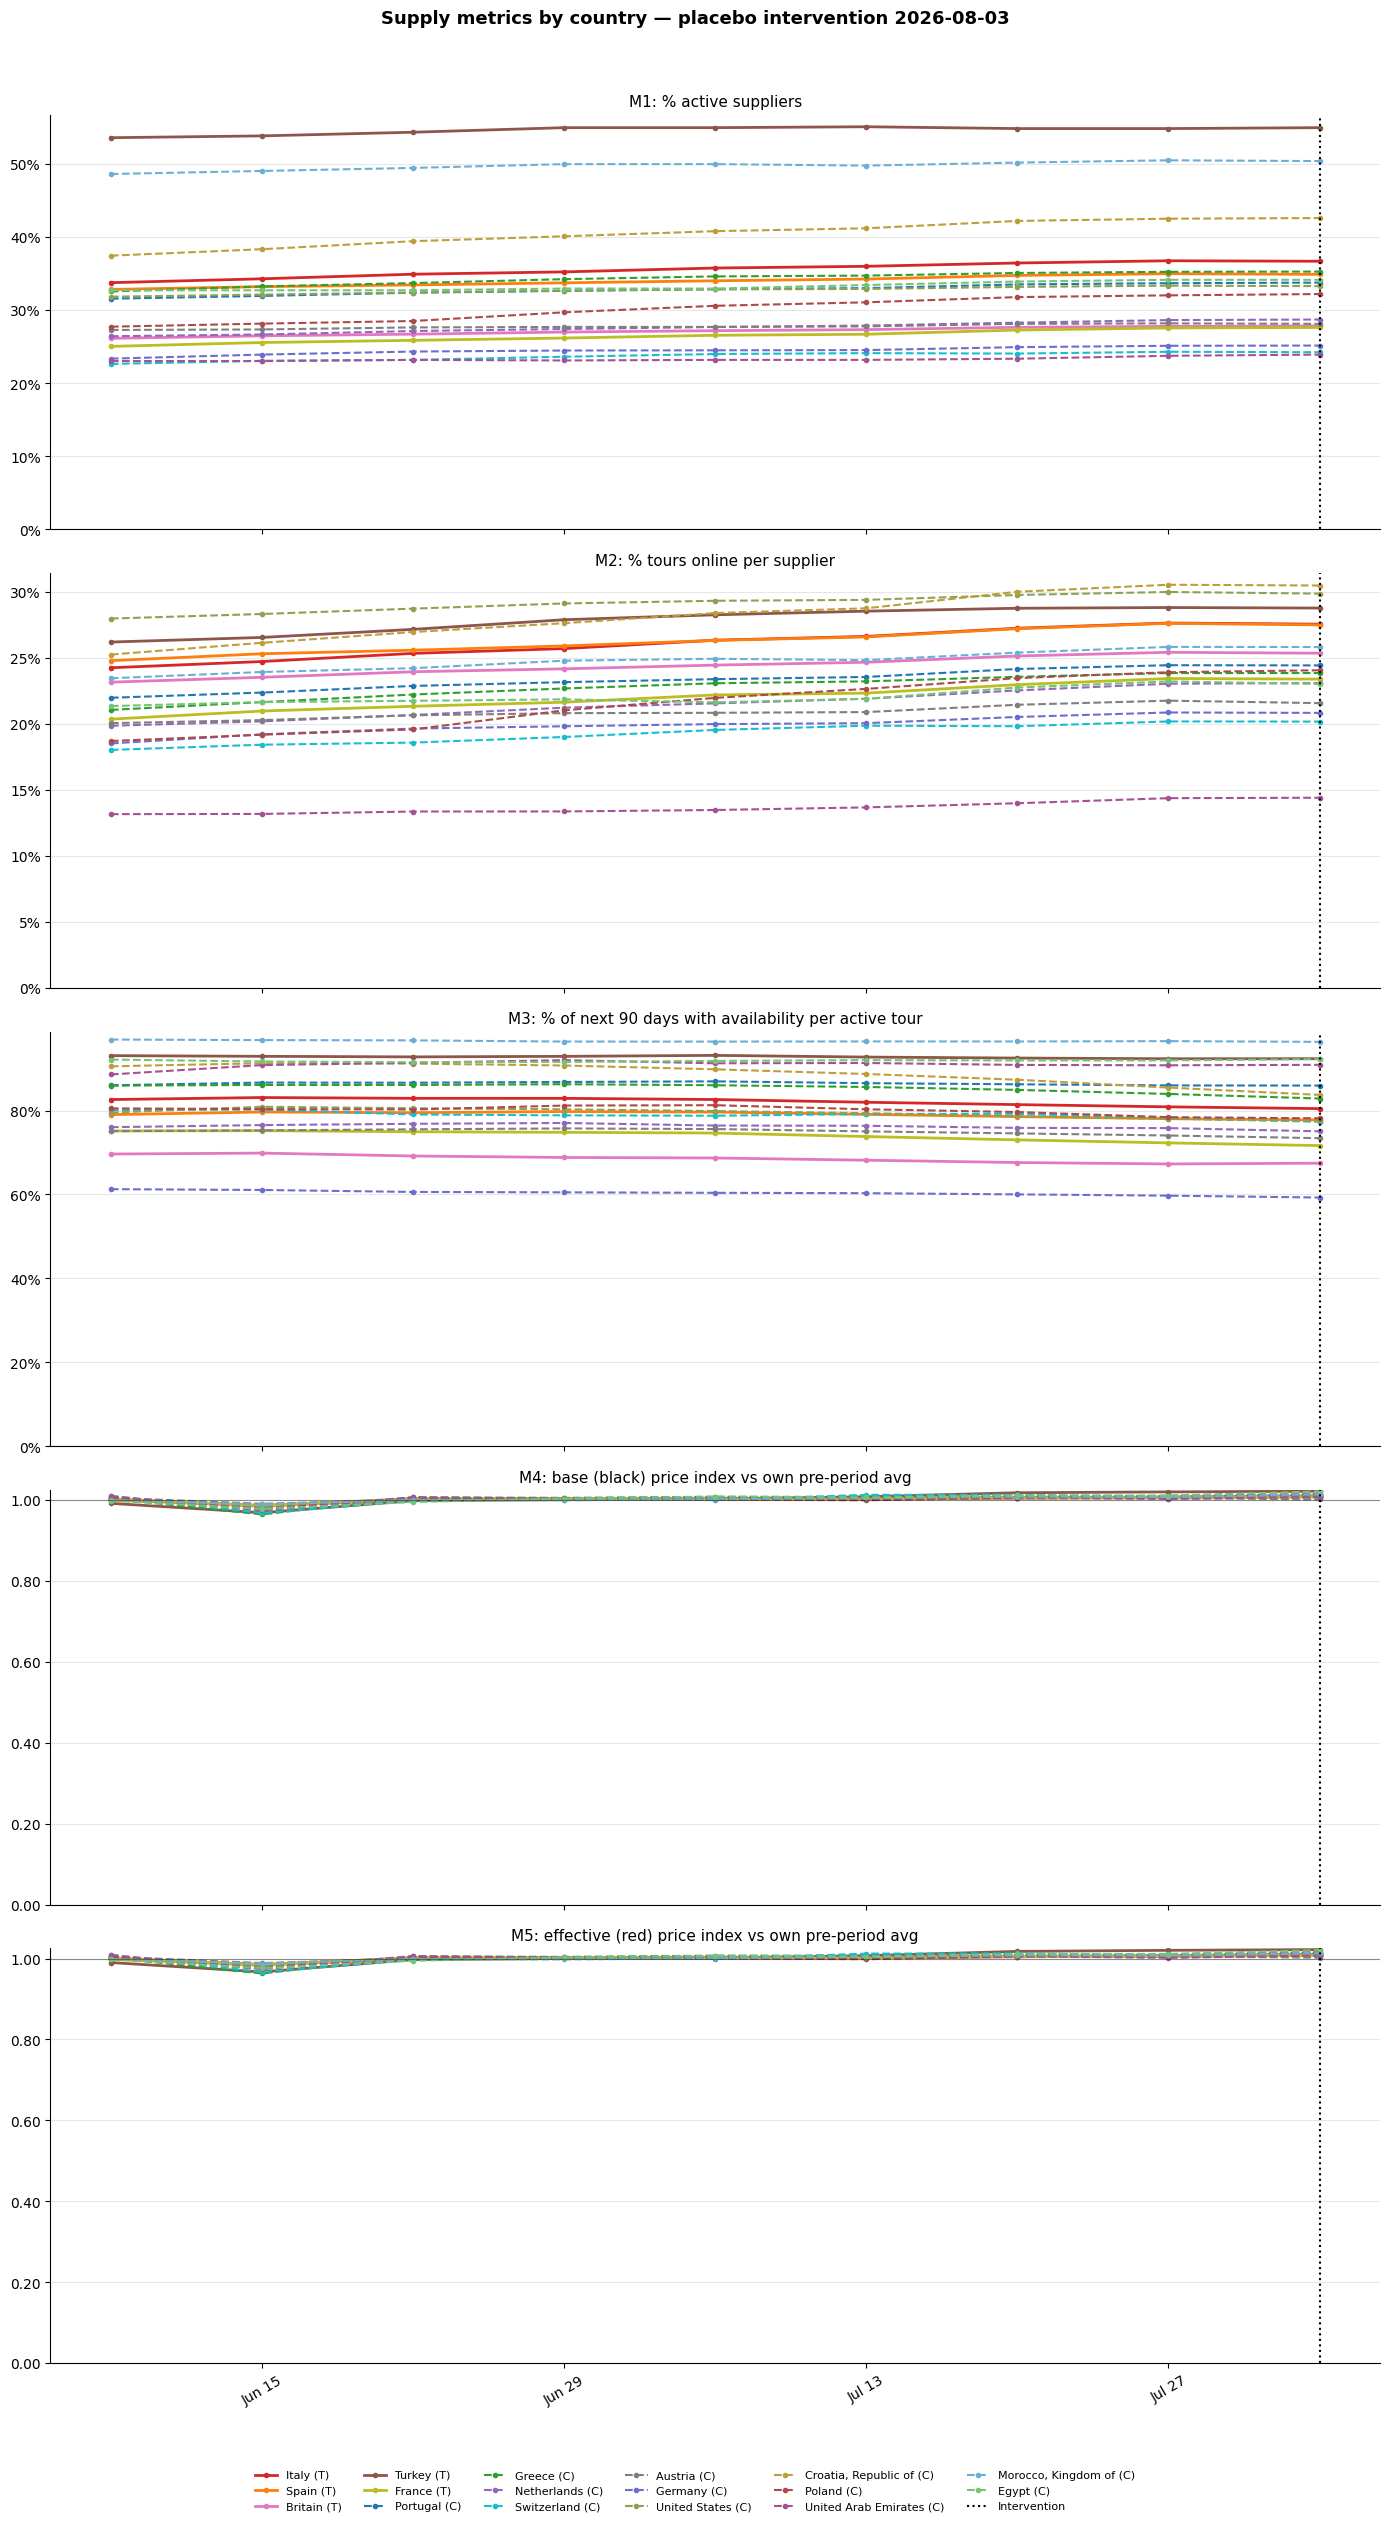

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TREATMENT = ['Italy', 'Spain', 'Britain', 'Turkey', 'France']
CONTROL   = ['Portugal', 'Greece', 'Netherlands', 'Switzerland', 'Austria', 'Germany',
             'United States', 'Croatia, Republic of', 'Poland',
             'United Arab Emirates', 'Morocco, Kingdom of', 'Egypt']

TREATMENT_COLORS = ['#d62728','#ff7f0e','#e377c2','#8c564b','#bcbd22']
CONTROL_COLORS   = ['#1f77b4','#2ca02c','#9467bd','#17becf','#7f7f7f','#6b6ecf',
                    '#8ca252','#bd9e39','#ad494a','#a55194','#6baed6','#74c476']

METRICS = [
    ("pct_active_suppliers",               "M1: % active suppliers",                                    "{:.0%}"),
    ("pct_tours_online_per_supplier",       "M2: % tours online per supplier",                           "{:.0%}"),
    ("pct_days_with_avail_per_active_tour", f"M3: % of next {COVERAGE_DAYS} days with availability per active tour", "{:.0%}"),
    ("price_index_black",                   "M4: base (black) price index vs own pre-period avg",        "{:.2f}"),
    ("price_index_effective",               "M5: effective (red) price index vs own pre-period avg",     "{:.2f}"),
]

intervention = pd.Timestamp(INTERVENTION_DATE)

fig, axes = plt.subplots(len(METRICS), 1, figsize=(14, 5 * len(METRICS)), sharex=True)
fig.suptitle("Supply metrics by country — placebo intervention " + INTERVENTION_DATE,
             fontsize=13, fontweight="bold", y=0.995)

for ax, (col, title, fmt) in zip(axes, METRICS):
    for country, color in zip(TREATMENT, TREATMENT_COLORS):
        sub = dfm[dfm["country_name"] == country].sort_values("week_start")
        ax.plot(sub["week_start"], sub[col], color=color, linewidth=2,
                label=country + " (T)", marker="o", markersize=3)
    for country, color in zip(CONTROL, CONTROL_COLORS):
        sub = dfm[dfm["country_name"] == country].sort_values("week_start")
        ax.plot(sub["week_start"], sub[col], color=color, linewidth=1.5,
                linestyle="--", label=country + " (C)", marker="o", markersize=3)

    ax.axvline(intervention, color="black", linewidth=1.5, linestyle=":", label="Intervention")
    if col.startswith("price_index"):
        ax.axhline(1.0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _, f=fmt: f.format(x)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

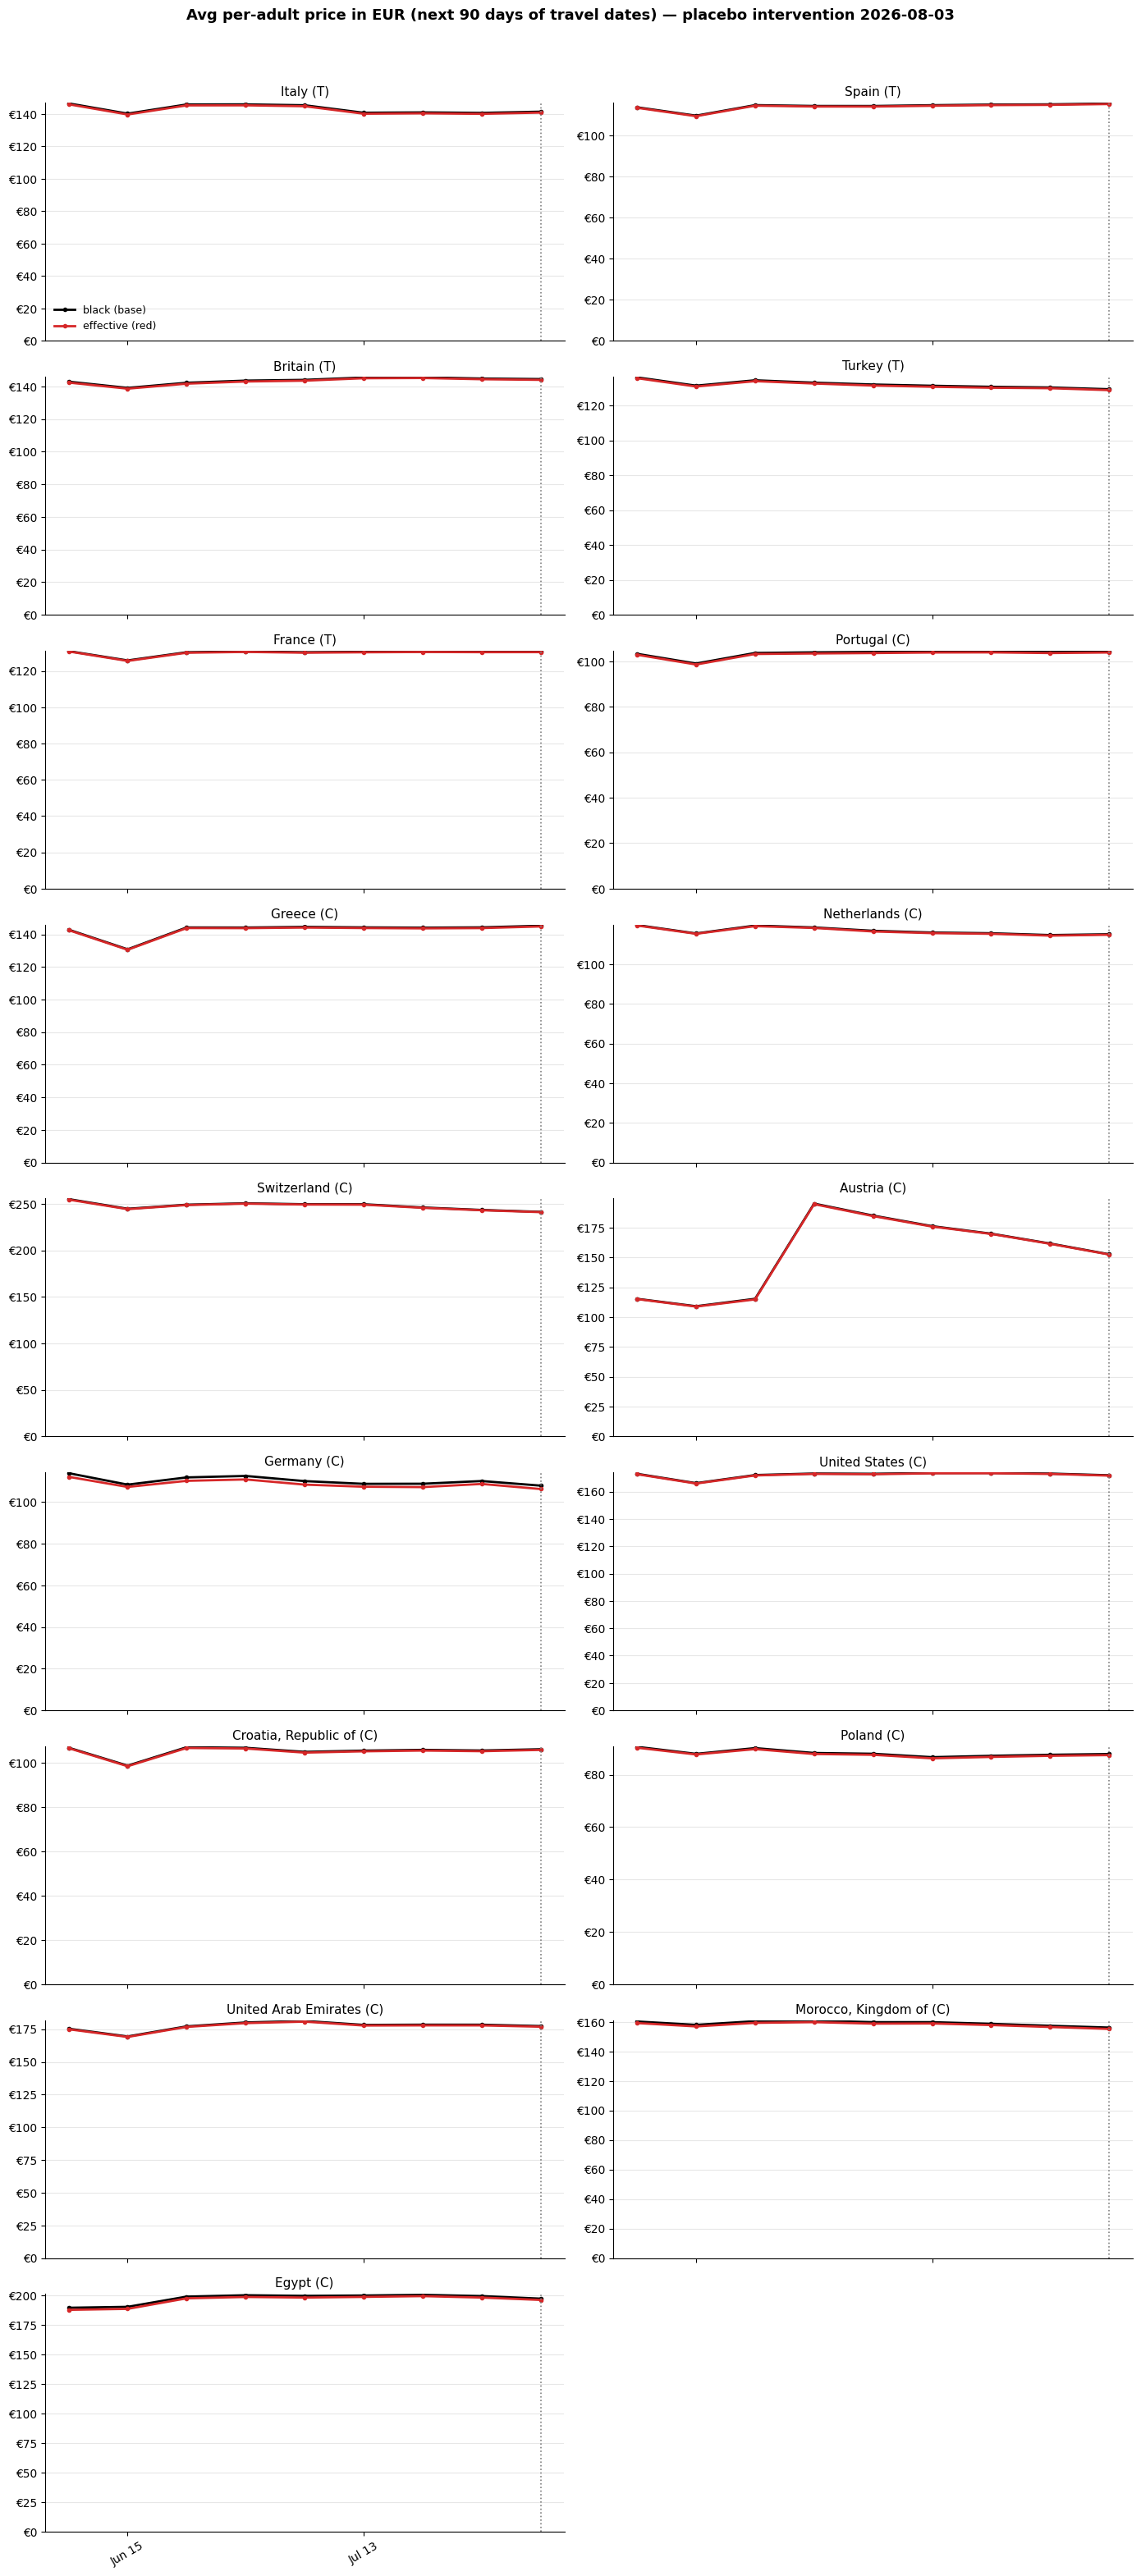

In [8]:
# Average per-adult price levels in EUR — one panel per country,
# black = base price, red line = effective (discounted) price
ALL_COUNTRIES = TREATMENT + CONTROL

_rows = (len(ALL_COUNTRIES) + 1) // 2
fig, axes = plt.subplots(_rows, 2, figsize=(14, 3.5 * _rows), sharex=True)
fig.suptitle("Avg per-adult price in EUR (next %d days of travel dates) — placebo intervention %s"
             % (COVERAGE_DAYS, INTERVENTION_DATE),
             fontsize=13, fontweight="bold", y=0.995)

for ax, country in zip(axes.flat, ALL_COUNTRIES):
    sub = dfm[dfm["country_name"] == country].sort_values("week_start")
    group = "T" if country in TREATMENT else "C"

    ax.plot(sub["week_start"], sub["avg_price_black_eur"], color="black", linewidth=2,
            label="black (base)", marker="o", markersize=3)
    ax.plot(sub["week_start"], sub["avg_price_effective_eur"], color="#d62728", linewidth=2,
            label="effective (red)", marker="o", markersize=3)

    ax.axvline(intervention, color="grey", linewidth=1.2, linestyle=":")
    ax.set_title(f"{country} ({group})", fontsize=11)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=4))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

for _ax in axes.flat[len(ALL_COUNTRIES):]:
    _ax.set_visible(False)
axes.flat[0].legend(fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

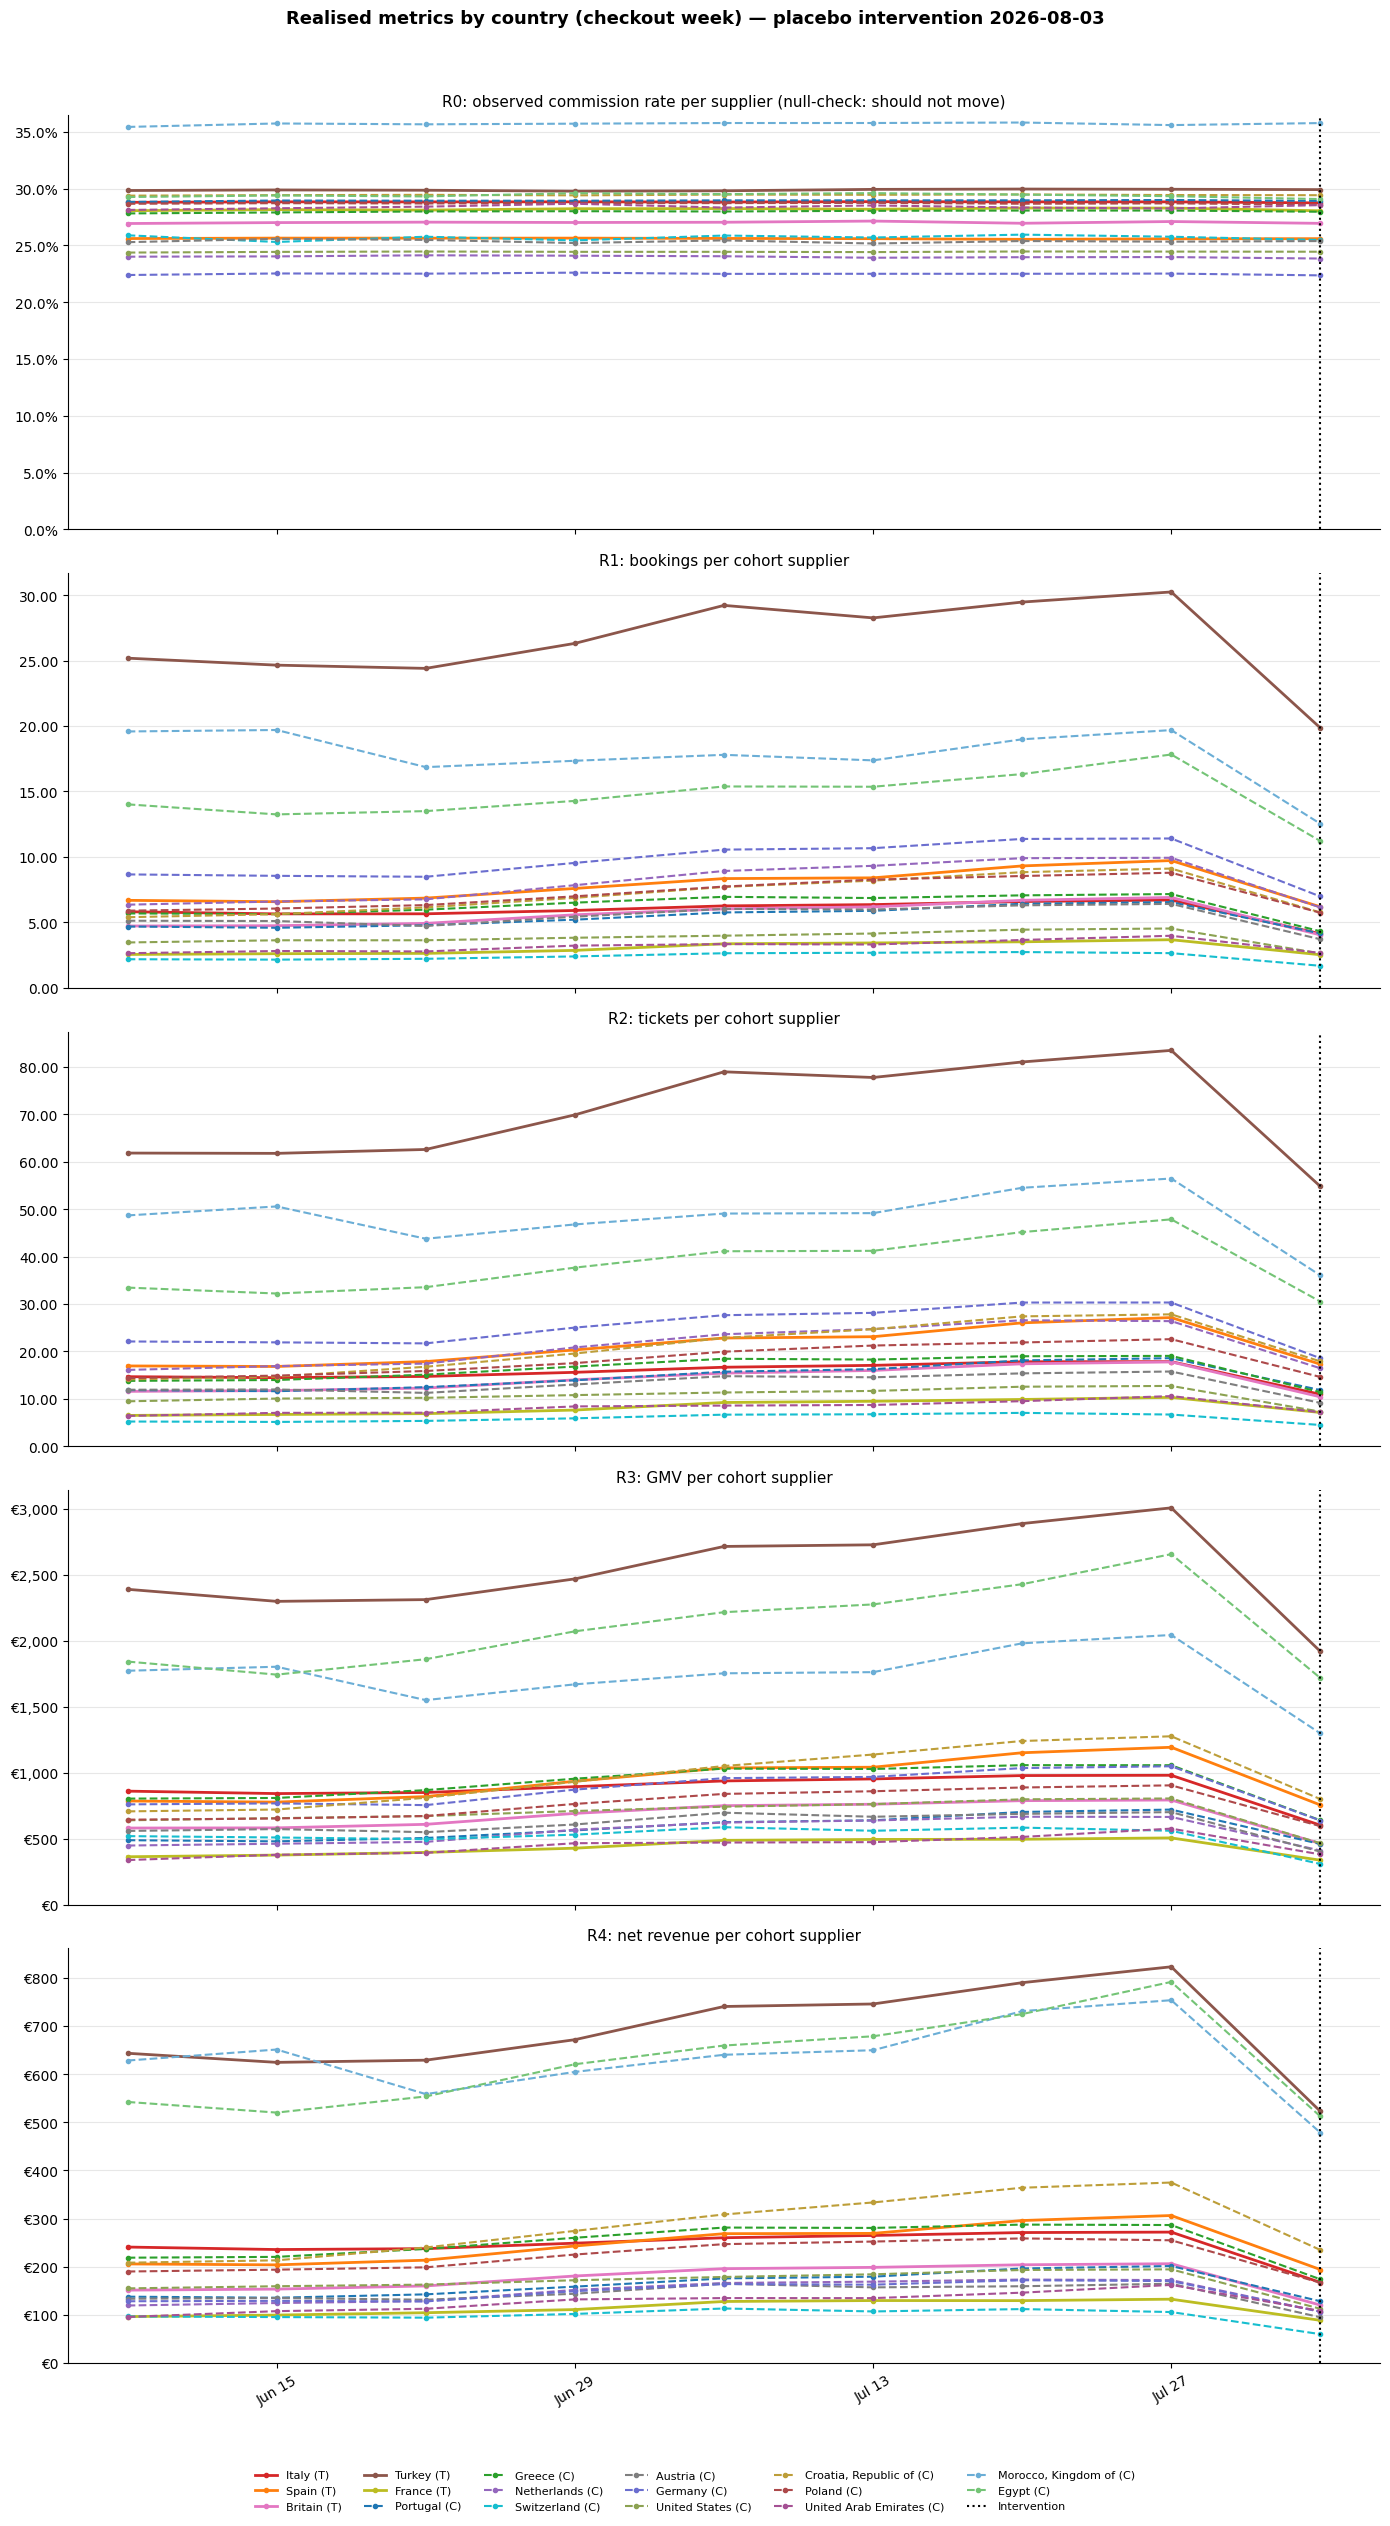

In [9]:
# Realised metrics per cohort supplier, by checkout week — treatment vs control
REALISED_METRICS = [
    ("commission_rate_per_supplier", "R0: observed commission rate per supplier (null-check: should not move)", "{:.1%}"),
    ("bookings_per_supplier",  "R1: bookings per cohort supplier",   "{:.2f}"),
    ("tickets_per_supplier",   "R2: tickets per cohort supplier",    "{:.2f}"),
    ("gmv_per_supplier",       "R3: GMV per cohort supplier",        "€{:,.0f}"),
    ("nr_per_supplier",        "R4: net revenue per cohort supplier","€{:,.0f}"),
]

fig, axes = plt.subplots(len(REALISED_METRICS), 1, figsize=(14, 5 * len(REALISED_METRICS)), sharex=True)
fig.suptitle("Realised metrics by country (checkout week) — placebo intervention " + INTERVENTION_DATE,
             fontsize=13, fontweight="bold", y=0.995)

for ax, (col, title, fmt) in zip(axes, REALISED_METRICS):
    for country, color in zip(TREATMENT, TREATMENT_COLORS):
        sub = dfm[dfm["country_name"] == country].sort_values("week_start")
        ax.plot(sub["week_start"], sub[col], color=color, linewidth=2,
                label=country + " (T)", marker="o", markersize=3)
    for country, color in zip(CONTROL, CONTROL_COLORS):
        sub = dfm[dfm["country_name"] == country].sort_values("week_start")
        ax.plot(sub["week_start"], sub[col], color=color, linewidth=1.5,
                linestyle="--", label=country + " (C)", marker="o", markersize=3)

    ax.axvline(intervention, color="black", linewidth=1.5, linestyle=":", label="Intervention")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _, f=fmt: f.format(x)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

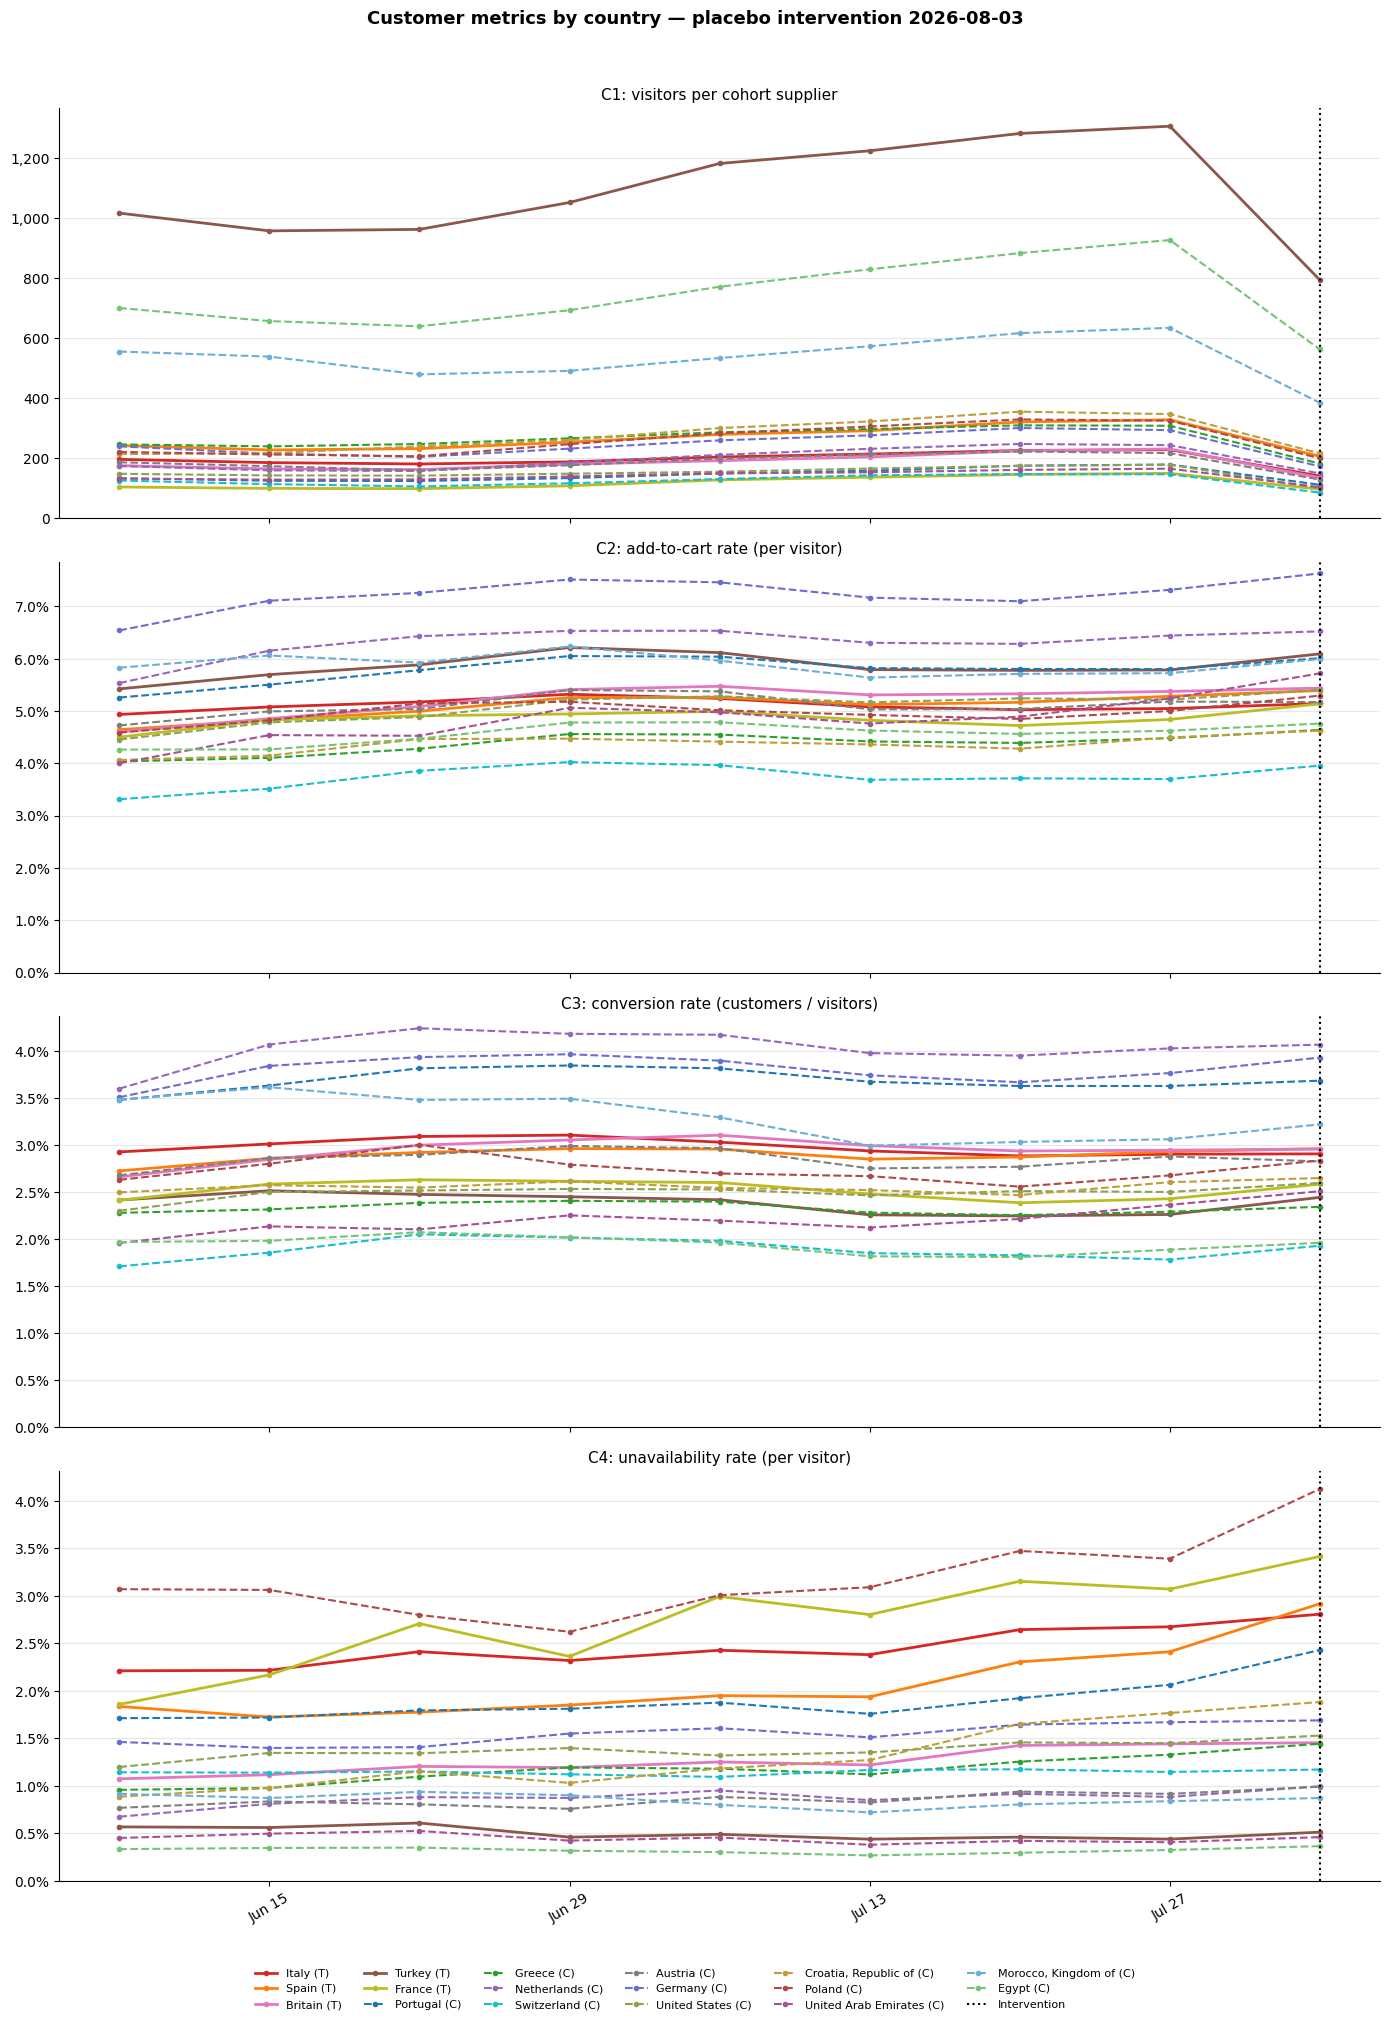

In [10]:
# Customer-side metrics — treatment vs control
CUSTOMER_METRICS = [
    ("visitors_per_supplier", "C1: visitors per cohort supplier",          "{:,.0f}"),
    ("add_to_cart_rate",      "C2: add-to-cart rate (per visitor)",        "{:.1%}"),
    ("conversion_rate",       "C3: conversion rate (customers / visitors)","{:.1%}"),
    ("unavailability_rate",   "C4: unavailability rate (per visitor)",     "{:.1%}"),
]

fig, axes = plt.subplots(len(CUSTOMER_METRICS), 1, figsize=(14, 5 * len(CUSTOMER_METRICS)), sharex=True)
fig.suptitle("Customer metrics by country — placebo intervention " + INTERVENTION_DATE,
             fontsize=13, fontweight="bold", y=0.995)

for ax, (col, title, fmt) in zip(axes, CUSTOMER_METRICS):
    for country, color in zip(TREATMENT, TREATMENT_COLORS):
        sub = dfm[dfm["country_name"] == country].sort_values("week_start")
        ax.plot(sub["week_start"], sub[col], color=color, linewidth=2,
                label=country + " (T)", marker="o", markersize=3)
    for country, color in zip(CONTROL, CONTROL_COLORS):
        sub = dfm[dfm["country_name"] == country].sort_values("week_start")
        ax.plot(sub["week_start"], sub[col], color=color, linewidth=1.5,
                linestyle="--", label=country + " (C)", marker="o", markersize=3)

    ax.axvline(intervention, color="black", linewidth=1.5, linestyle=":", label="Intervention")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _, f=fmt: f.format(x)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [11]:
# Synthetic control + DiD.
# Per metric x treatment country: each country's series is first normalised to its
# own pre-period mean (pre ~ 1.0), so weights match SHAPE/trend, not level - a
# convex combination of donors can otherwise never reach a country whose level
# sits outside the donor range (e.g. Turkey). Weights (non-negative, sum=1) are
# fit on the pre period; DiD = (treat post - pre) - (synthetic post - pre),
# directly in %-of-pre-mean terms.
# commission_rate_per_supplier is a NULL-CHECK: the DST surcharge is invoiced on
# top of the base commission and does NOT flow into fb.nr/fb.gmv, so this metric
# should stay flat even in the real run. If it moves, the booking-data definition
# changed underneath us. The actual dose is computed per supplier in the scoring
# cell: base_commission_rate x dst_surcharge_pct from dst_commission_country.
# Demand metrics run on YoY ratios (this week / same week LY on the same cohort
# tours) - the raw levels failed the placebo because of country-specific
# seasonal ramps. Raw levels kept alongside for comparison.
# Inference: placebo-in-space - each control country is fake-treated against the
# remaining controls; rank of the real |DiD| within the placebo |DiD|s.
from scipy.optimize import minimize

SYNTH_METRICS = [
    # null-check (surcharge is invoiced on top; observed rate should NOT move)
    "commission_rate_per_supplier",
    "commission_rate_per_supplier_yoy",
    # supply (validated)
    "pct_active_suppliers",
    "pct_tours_online_per_supplier",
    "pct_days_with_avail_per_active_tour",
    # price (validated; Turkey inflation caveat)
    "price_index_black",
    "price_index_effective",
    # demand - YoY ratios (primary)
    "bookings_yoy",
    "tickets_yoy",
    "gmv_yoy",
    "nr_yoy",
    "visitors_yoy",
    "conversion_rate_yoy",
    "add_to_cart_rate_yoy",
    "unavailability_rate_yoy",
    # demand - raw levels (reference; failed placebo as levels)
    "bookings_per_supplier",
    "gmv_per_supplier",
    "nr_per_supplier",
    "conversion_rate",
]

def fit_weights(X_pre, y_pre):
    """Non-negative weights summing to 1 that best reproduce y_pre from X_pre."""
    k = X_pre.shape[1]
    w0 = np.full(k, 1.0 / k)
    res = minimize(
        lambda w: np.sum((X_pre @ w - y_pre) ** 2), w0,
        bounds=[(0.0, 1.0)] * k,
        constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
        method="SLSQP",
    )
    return res.x

def synth_did(pivot_norm, treated, donors, pre_mask):
    """On pre-mean-normalised series. Returns weights, synthetic, DiD (as fraction
    of the treated country's pre mean), and pre-period fit RMSE (same units)."""
    y = pivot_norm[treated].values
    X = pivot_norm[donors].values
    w = fit_weights(X[pre_mask], y[pre_mask])
    synth = X @ w
    did = (y[~pre_mask].mean() - y[pre_mask].mean()) - (synth[~pre_mask].mean() - synth[pre_mask].mean())
    rmse = np.sqrt(np.mean((y[pre_mask] - synth[pre_mask]) ** 2))
    return w, synth, did, rmse

results = []
synth_series = {}   # (metric, country) -> DataFrame with actual & synthetic (original units)

for metric in SYNTH_METRICS:
    pivot = (dfm.pivot_table(index="week_start", columns="country_name", values=metric)
                .sort_index())
    pivot = pivot.dropna()   # drop weeks where any country is missing
    pre_mask = np.asarray(pivot.index < pd.Timestamp(INTERVENTION_DATE))
    if pivot.empty or pre_mask.sum() < 8 or (~pre_mask).sum() < 1:
        print(f"skipping {metric}: needs the full 8-week pre-period and at least one post week")
        continue

    # normalise every country to its own pre-period mean -> pre ~ 1.0 for all
    pre_means  = pivot[pre_mask].mean()
    pivot_norm = pivot / pre_means

    for treated in TREATMENT:
        w, synth_norm, did, rmse = synth_did(pivot_norm, treated, CONTROL, pre_mask)

        # placebo-in-space: fake-treat each control against the remaining controls
        placebo_dids = []
        for fake in CONTROL:
            donors = [c for c in CONTROL if c != fake]
            _, _, p_did, _ = synth_did(pivot_norm, fake, donors, pre_mask)
            placebo_dids.append(p_did)
        n_larger = sum(abs(p) >= abs(did) for p in placebo_dids)

        results.append({
            "metric": metric,
            "country": treated,
            "treat_pre_mean": pre_means[treated],
            "did_pct_of_pre": did,           # normalised scale: already % of pre mean
            "pre_fit_rmse_pct": rmse,        # same scale
            "placebos_larger": f"{n_larger}/5",
            "weights": {c: round(x, 2) for c, x in zip(CONTROL, w) if x > 0.01},
        })
        # back to original units for plotting
        synth_series[(metric, treated)] = pd.DataFrame(
            {"actual": pivot[treated].values,
             "synthetic": synth_norm * pre_means[treated]},
            index=pivot.index,
        )

synth_results = pd.DataFrame(results)

# summary: DiD as % of treatment pre-period mean (expect ~0 for the placebo run)
summary = (synth_results
           .pivot_table(index="metric", columns="country", values="did_pct_of_pre")
           .reindex(SYNTH_METRICS)[TREATMENT])
print(f"DiD as % of pre-period mean — intervention {INTERVENTION_DATE}")
print((summary * 100).round(1).to_string())
print("\nPre-fit quality (RMSE as % of pre mean, lower = better fit):")
fit_summary = (synth_results
               .pivot_table(index="metric", columns="country", values="pre_fit_rmse_pct")
               .reindex(SYNTH_METRICS)[TREATMENT])
print((fit_summary * 100).round(1).to_string())

DiD as % of pre-period mean — intervention 2026-08-03
country                              Italy  Spain  Britain  Turkey  France
metric                                                                    
commission_rate_per_supplier          -0.0    0.2     -0.1     0.4    -0.3
commission_rate_per_supplier_yoy      -0.4   -0.4     -0.5    -0.1    -0.4
pct_active_suppliers                  -0.4   -0.2     -0.1    -1.2     0.5
pct_tours_online_per_supplier         -0.5   -0.3     -0.4    -1.0     0.1
pct_days_with_avail_per_active_tour   -0.3    0.2      1.8     0.9     0.3
price_index_black                     -0.1   -0.2     -0.0     1.2    -0.3
price_index_effective                 -0.1   -0.2     -0.1     1.2    -0.3
bookings_yoy                           0.7    0.3      0.2     1.4     1.9
tickets_yoy                           -1.9   -1.2     -1.5     4.2    -1.3
gmv_yoy                               -1.5    0.0     -3.2     5.0     1.7
nr_yoy                                -1.6    

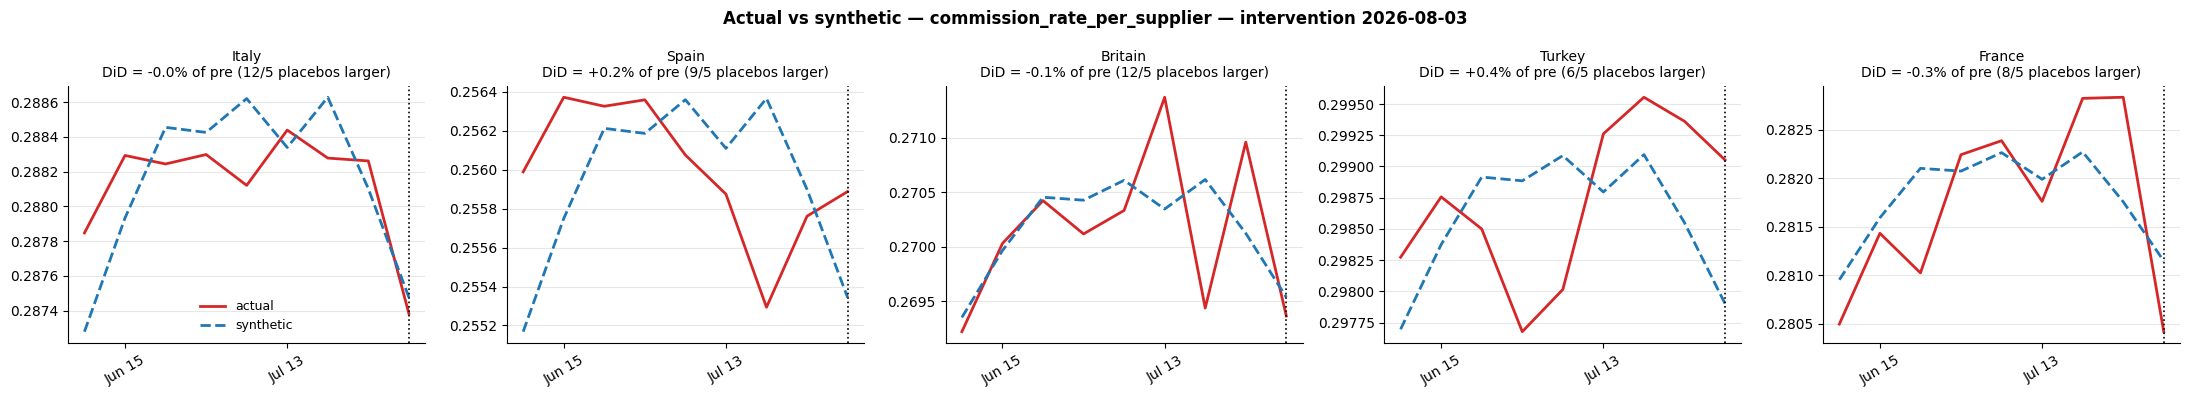

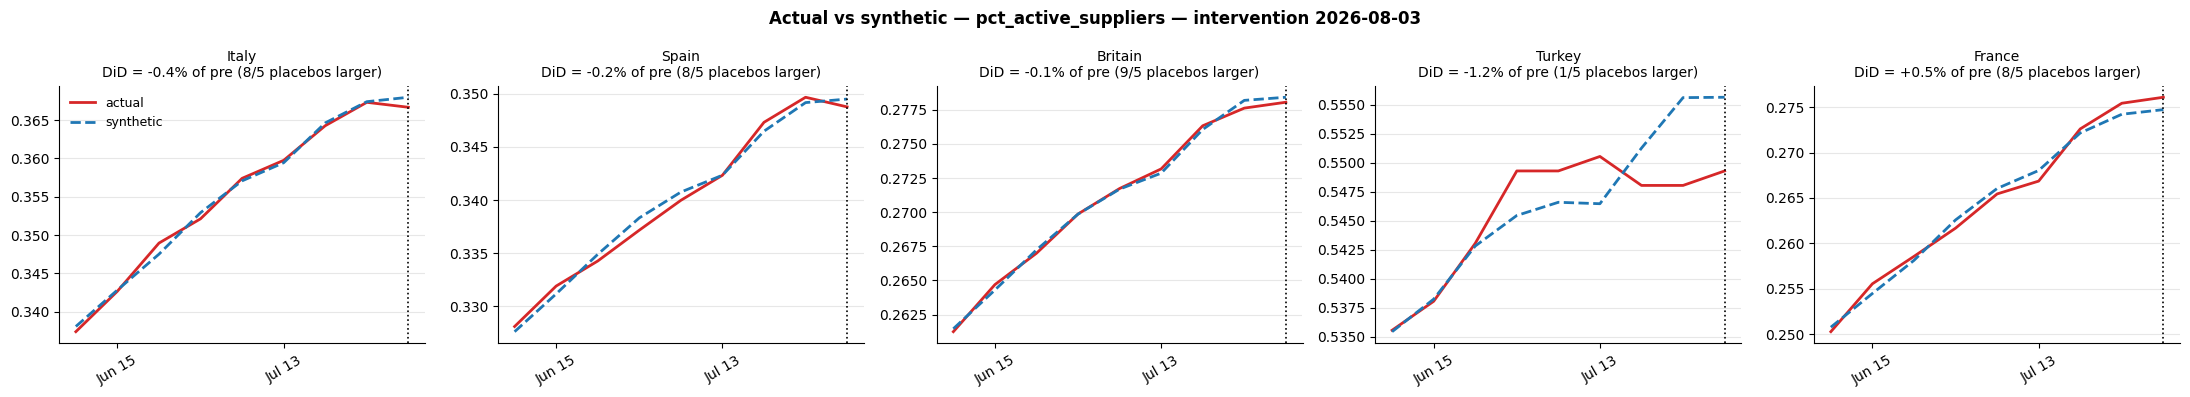

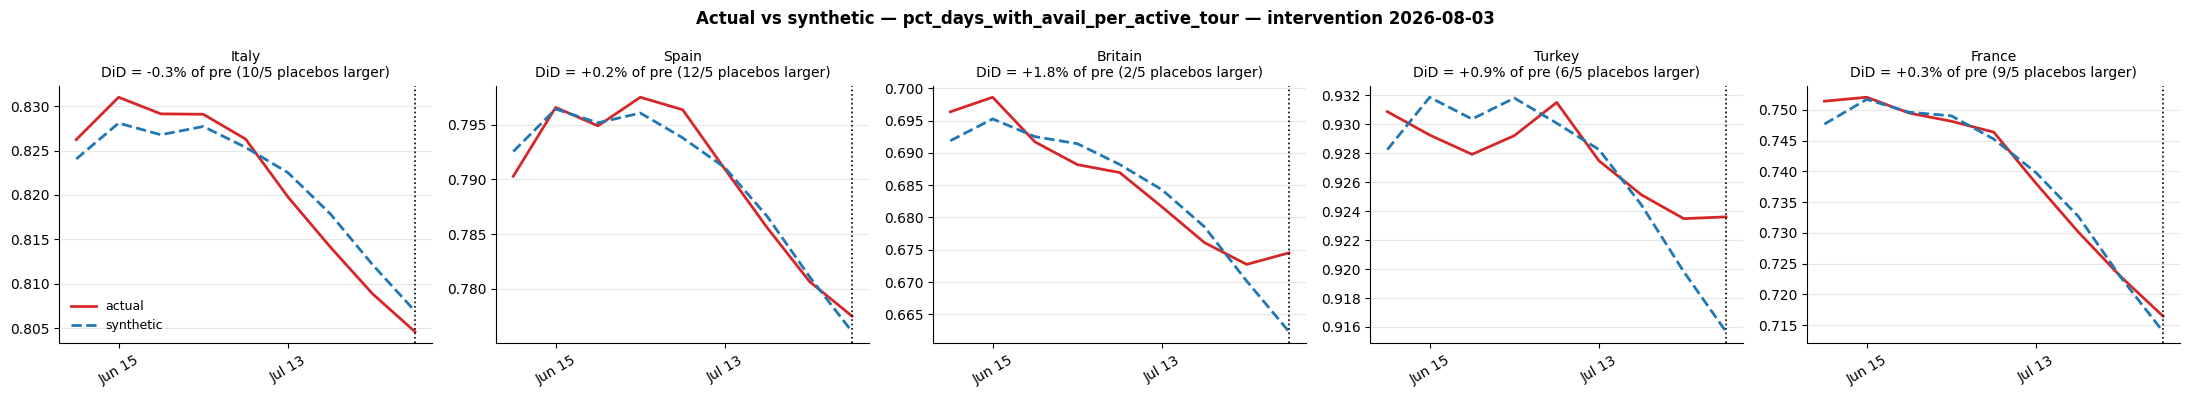

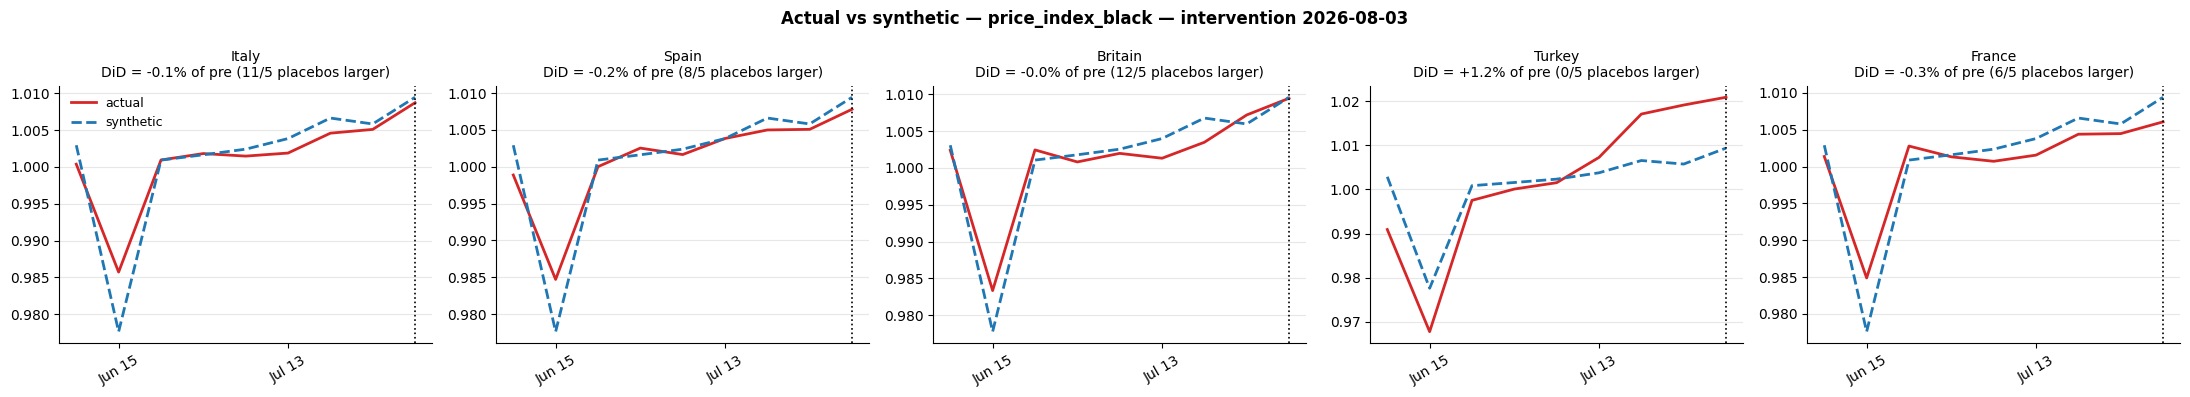

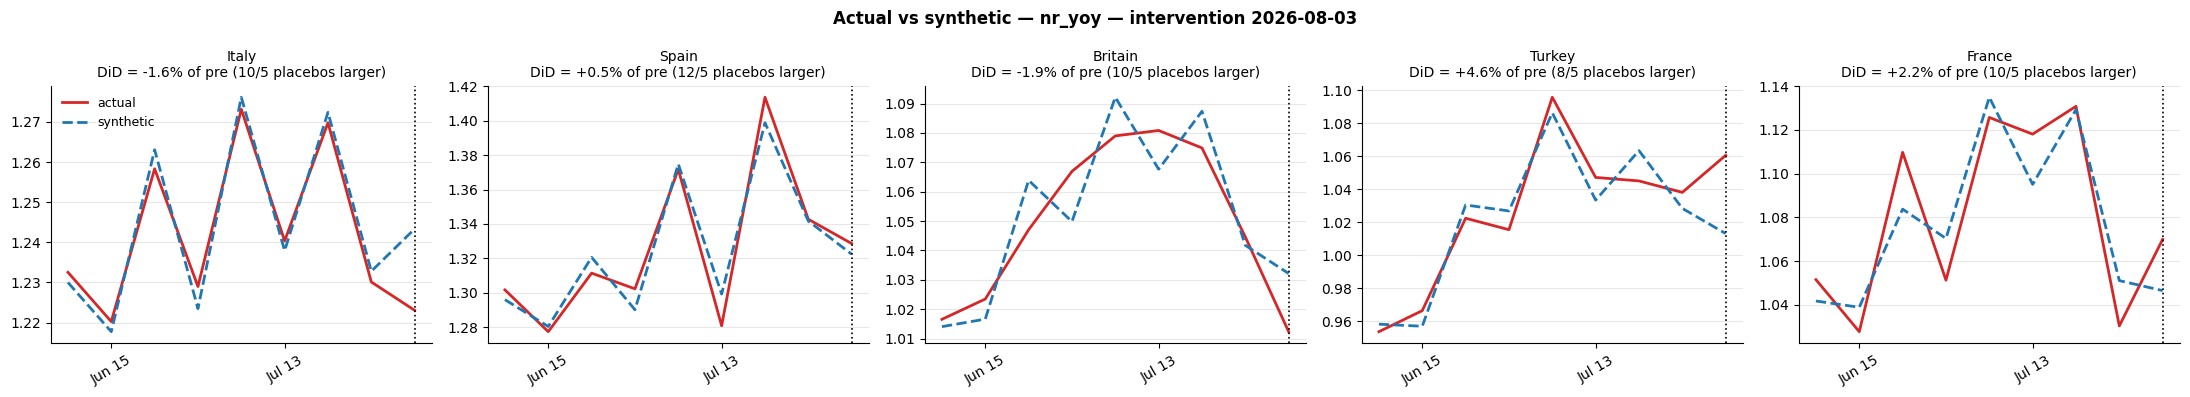

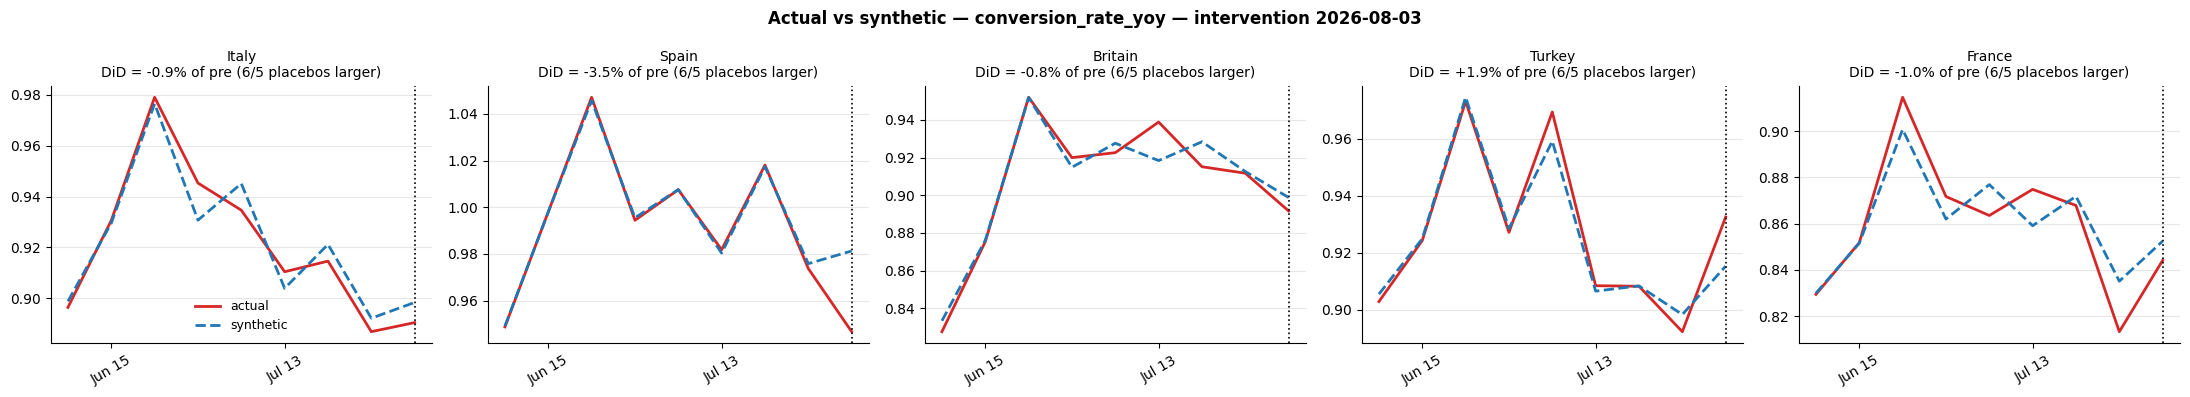

In [12]:
# Inspect actual vs synthetic for one metric across the 5 treatment countries.
if "synth_series" not in globals():
    raise RuntimeError("Run the 'Synthetic control + DiD' cell first - it builds synth_series/synth_results used here.")

def plot_synth(metric):
    fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharex=True)
    fig.suptitle(f"Actual vs synthetic — {metric} — intervention {INTERVENTION_DATE}",
                 fontsize=12, fontweight="bold")
    for ax, treated in zip(axes, TREATMENT):
        s = synth_series.get((metric, treated))
        if s is None:
            ax.set_title(f"{treated} (no data)")
            continue
        ax.plot(s.index, s["actual"], color="#d62728", linewidth=2, label="actual")
        ax.plot(s.index, s["synthetic"], color="#1f77b4", linewidth=2,
                linestyle="--", label="synthetic")
        ax.axvline(intervention, color="black", linewidth=1.2, linestyle=":")
        row = synth_results[(synth_results["metric"] == metric)
                            & (synth_results["country"] == treated)].iloc[0]
        ax.set_title(f"{treated}\nDiD = {row['did_pct_of_pre']:+.1%} of pre "
                     f"({row['placebos_larger']} placebos larger)", fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=4))
        ax.tick_params(axis="x", rotation=30)
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)
    axes[0].legend(fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

# key metric from each family; call plot_synth(...) for any other
for m in ["commission_rate_per_supplier",
          "pct_active_suppliers",
          "pct_days_with_avail_per_active_tour",
          "price_index_black",
          "nr_yoy",
          "conversion_rate_yoy"]:
    plot_synth(m)

In [13]:
# Publish synthetic-control outputs to Databricks for the Looker dashboard.
# Two tables in production.supply_analytics:
#   dst_synthetic_control_series  - actual vs synthetic per scenario x metric x country x week.
#       actual/synthetic are in natural metric units (YoY ratios, shares, indices);
#       actual_absolute/synthetic_absolute are STORY units: per-supplier levels
#       for the YoY volume metrics (via the same-week-LY base implied by the
#       ratio), EUR per tour for the price indices, natural units for the other
#       rates/shares. Country totals = value x cohort_suppliers (volume metrics).
#   dst_synthetic_control_results - DiD, fit quality, placebo count, donor weights,
#       plus did_absolute = average weekly post-period gap (actual - synthetic) in
#       story units, e.g. "-10,500 bookings/week", "-180,000 EUR NR/week".
# Absolute numbers reconcile to COHORT volumes (winsorised) - not company-wide reports.
# Re-run after each notebook run (per scenario); rows for the current scenario are replaced.
SCENARIO = {"2025-10-06": "placebo", "2026-08-03": "real"}.get(INTERVENTION_DATE, INTERVENTION_DATE)

run_sql("""
CREATE TABLE IF NOT EXISTS production.supply_analytics.dst_synthetic_control_series (
  scenario STRING, metric STRING, country_name STRING, week_start DATE,
  actual DOUBLE, synthetic DOUBLE, actual_absolute DOUBLE, synthetic_absolute DOUBLE,
  cohort_suppliers DOUBLE) USING DELTA
""")
run_sql("""
CREATE TABLE IF NOT EXISTS production.supply_analytics.dst_synthetic_control_results (
  scenario STRING, metric STRING, country_name STRING,
  did_pct_of_pre DOUBLE, pre_fit_rmse_pct DOUBLE, placebos_larger STRING, donor_weights STRING,
  did_absolute DOUBLE, cohort_suppliers DOUBLE) USING DELTA
""")
# tables created before the absolute columns existed: append them (no-op once added)
for stmt in (
    "ALTER TABLE production.supply_analytics.dst_synthetic_control_series ADD COLUMNS (actual_absolute DOUBLE)",
    "ALTER TABLE production.supply_analytics.dst_synthetic_control_series ADD COLUMNS (synthetic_absolute DOUBLE)",
    "ALTER TABLE production.supply_analytics.dst_synthetic_control_results ADD COLUMNS (did_absolute DOUBLE)",
    "ALTER TABLE production.supply_analytics.dst_synthetic_control_series ADD COLUMNS (cohort_suppliers DOUBLE)",
    "ALTER TABLE production.supply_analytics.dst_synthetic_control_results ADD COLUMNS (cohort_suppliers DOUBLE)",
):
    try:
        run_sql(stmt)
    except Exception:
        pass  # column already exists

run_sql(f"DELETE FROM production.supply_analytics.dst_synthetic_control_series WHERE scenario = '{SCENARIO}'")
run_sql(f"DELETE FROM production.supply_analytics.dst_synthetic_control_results WHERE scenario = '{SCENARIO}'")

# story-unit conversion for YoY metrics: base column in dfm (+ whether it is a
# per-supplier level that needs scaling by the fixed cohort size to give totals)
# story units are PER SUPPLIER (consistent with the monitoring tiles); country
# totals = per-supplier value x cohort_suppliers, stored alongside for LookML
# each ratio metric is rescaled to intuitive units via the weekly base implied by
# the ratio itself: YoY -> the same-week-LY per-supplier level; price index -> the
# EUR price per tour. The scale multiplies actual and twin identically, so the
# displayed gap stays exactly the quoted DiD.
YOY_BASE = {
    "bookings_yoy":                      "bookings_per_supplier",
    "tickets_yoy":                       "tickets_per_supplier",
    "gmv_yoy":                           "gmv_per_supplier",
    "nr_yoy":                            "nr_per_supplier",
    "visitors_yoy":                      "visitors_per_supplier",
    "conversion_rate_yoy":               "conversion_rate",
    "add_to_cart_rate_yoy":              "add_to_cart_rate",
    "unavailability_rate_yoy":           "unavailability_rate",
    "commission_rate_per_supplier_yoy":  "commission_rate_per_supplier",
    "price_index_black":                 "avg_price_black_eur",
    "price_index_effective":             "avg_price_effective_eur",
}

def _fmt(x):
    return "NULL" if x is None or pd.isna(x) or not np.isfinite(x) else repr(float(x))

rows = []
did_absolute = {}   # (metric, country) -> avg weekly post gap in story units
for (metric, country), s in synth_series.items():
    sub = dfm[dfm["country_name"] == country].set_index("week_start")
    cohort_n = float(sub["cohort_suppliers"].iloc[0])
    pre = s.index < pd.Timestamp(INTERVENTION_DATE)
    # DiD level correction: shift the twin so its pre-period mean equals actual's -
    # the same second difference the official % DiD applies. The displayed post-period
    # gap then matches did_pct_of_pre in sign and story (raw synthetic column unchanged)
    synth_adj = s["synthetic"] + (s["actual"][pre].mean() - s["synthetic"][pre].mean())
    if metric in YOY_BASE:
        base = sub[YOY_BASE[metric]].astype(float).reindex(s.index)
        ly_base = base / s["actual"].replace(0, np.nan)   # same-week-LY base implied by the YoY ratio
        actual_abs = base
        synth_abs = synth_adj * ly_base
    else:
        actual_abs = s["actual"]                          # per-supplier levels / rates / indices
        synth_abs = synth_adj
    post = ~pre
    gap = (actual_abs - synth_abs)[post].dropna()
    did_absolute[(metric, country)] = float(gap.mean()) if len(gap) else None
    c_esc = country.replace(chr(39), chr(39) * 2)
    for ws, a, syn, aa, sa in zip(s.index, s["actual"], s["synthetic"], actual_abs, synth_abs):
        rows.append(f"('{SCENARIO}','{metric}','{c_esc}',DATE'{ws.date()}',{_fmt(a)},{_fmt(syn)},{_fmt(aa)},{_fmt(sa)},{cohort_n})")
for i in range(0, len(rows), 500):
    run_sql("INSERT INTO production.supply_analytics.dst_synthetic_control_series "
            "(scenario, metric, country_name, week_start, actual, synthetic, actual_absolute, synthetic_absolute, cohort_suppliers) VALUES "
            + ",".join(rows[i:i+500]))

# results
import json as _json
cohort_by_country = {c: float(dfm[dfm["country_name"] == c]["cohort_suppliers"].iloc[0])
                     for c in dfm["country_name"].unique()}
rrows = []
for _, r in synth_results.iterrows():
    w = _json.dumps(r["weights"]).replace("'", "''")
    c = r["country"].replace("'", "''")
    d_abs = _fmt(did_absolute.get((r["metric"], r["country"])))
    rrows.append(f"('{SCENARIO}','{r.metric}','{c}',{r.did_pct_of_pre},{r.pre_fit_rmse_pct},'{r.placebos_larger}','{w}',{d_abs},{cohort_by_country[r['country']]})")
run_sql("INSERT INTO production.supply_analytics.dst_synthetic_control_results "
        "(scenario, metric, country_name, did_pct_of_pre, pre_fit_rmse_pct, placebos_larger, donor_weights, did_absolute, cohort_suppliers) VALUES "
        + ",".join(rrows))

print(f"published scenario '{SCENARIO}': {len(rows)} series rows, {len(rrows)} result rows")
print("\navg weekly post-period gap vs twin (story units, per supplier):")
vol = ["bookings_yoy", "nr_yoy", "gmv_yoy", "visitors_yoy", "pct_active_suppliers"]
for m in vol:
    line = "  ".join(f"{c}: {did_absolute.get((m, c)):+,.2f}" for c in TREATMENT
                     if did_absolute.get((m, c)) is not None)
    print(f"{m:>22}  {line}")


/Users/shazeb.asad/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Databricks CLI v0.296.0 found at /opt/homebrew/bin/databricks
Your current $PATH prefers running CLI v0.18.0 at /Users/shazeb.asad/Library/Python/3.9/bin/databricks

Because both are installed and available in $PATH, I assume you are trying to run the newer version.
If you want to disable this behavior you can set DATABRICKS_CLI_DO_NOT_EXECUTE_NEWER_VERSION=1.

Executing CLI v0.296.0...
-------------------------
/Users/shazeb.asad/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Databricks CLI v0.296.0 foun

published scenario 'real': 855 series rows, 95 result rows

avg weekly post-period gap vs twin (story units, per supplier):
          bookings_yoy  Italy: +0.03  Spain: +0.02  Britain: +0.01  Turkey: +0.26  France: +0.05
                nr_yoy  Italy: -2.78  Spain: +0.90  Britain: -2.35  Turkey: +23.36  France: +1.94
               gmv_yoy  Italy: -9.34  Spain: +0.13  Britain: -15.51  Turkey: +92.22  France: +5.75
          visitors_yoy  Italy: +0.55  Spain: +5.57  Britain: -0.78  Turkey: +0.16  France: +1.05
  pct_active_suppliers  Italy: -0.00  Spain: -0.00  Britain: -0.00  Turkey: -0.01  France: +0.00


In [14]:
# Donor usage: which control countries actually get weight?
# A donor with ~0 avg weight everywhere is never used by the optimiser and can
# be dropped (saves query time; no statistical loss). Judge on PRIMARY metrics.
PRIMARY = ["pct_active_suppliers", "pct_tours_online_per_supplier",
           "pct_days_with_avail_per_active_tour", "price_index_black",
           "price_index_effective", "bookings_yoy", "tickets_yoy",
           "gmv_yoy", "nr_yoy", "visitors_yoy", "conversion_rate_yoy"]

rows = []
for _, r in synth_results.iterrows():
    if r["metric"] not in PRIMARY:
        continue
    for donor in CONTROL:
        rows.append({"metric": r["metric"], "treated": r["country"],
                     "donor": donor, "weight": r["weights"].get(donor, 0.0)})
wdf = pd.DataFrame(rows)

print("Avg weight per donor (across all primary metric x country models):")
overall = (wdf.groupby("donor")["weight"].agg(["mean", lambda s: (s > 0.05).mean()])
              .rename(columns={"mean": "avg_weight", "<lambda_0>": "share_models_used"})
              .sort_values("avg_weight", ascending=False))
print(overall.round(3).to_string())

print("\nAvg weight per donor x treated country:")
per_treat = (wdf.pivot_table(index="donor", columns="treated", values="weight", aggfunc="mean")
                [TREATMENT].sort_values("Turkey", ascending=False))
print(per_treat.round(3).to_string())

print("\nDonors with avg weight < 0.03 and used in <10% of models -> candidates to drop:")
drop = overall[(overall["avg_weight"] < 0.03) & (overall["share_models_used"] < 0.10)]
print(drop.round(3).to_string() if len(drop) else "(none - all donors contribute)")

Avg weight per donor (across all primary metric x country models):
                      avg_weight  share_models_used
donor                                              
Greece                     0.130              0.745
United States              0.111              0.727
Portugal                   0.106              0.709
Switzerland                0.099              0.709
Egypt                      0.084              0.673
Croatia, Republic of       0.077              0.545
Austria                    0.073              0.618
Netherlands                0.072              0.545
Germany                    0.067              0.618
Poland                     0.066              0.491
Morocco, Kingdom of        0.065              0.582
United Arab Emirates       0.039              0.364

Avg weight per donor x treated country:
treated               Italy  Spain  Britain  Turkey  France
donor                                                      
Poland                0.056  0.030    0.024 

In [15]:
# Layer 3: supplier-level impact scoring.
# Per supplier: pre vs post values on activity, portfolio, coverage, price and
# bookings/GMV/NR. Runs for BOTH treatment and control suppliers - control
# deltas provide the benchmark ("what changed for comparable suppliers with no
# DST"), which is subtracted from treatment deltas in the next cell.

supplier_query = f"""
WITH
cohort AS (
  -- LOCKED POOL: every gyg_status-active supplier as of 2026-08-04
  -- (production.supply_analytics.dst_supplier_pool, 17 countries, frozen).
  -- The pool IS the cohort - no further filters. Tours attach via LEFT JOIN:
  -- pool suppliers without a listed tour stay in the denominator.
  SELECT DISTINCT
    p.supplier_id,
    p.country_name,
    t.tour_id
  FROM production.supply_analytics.dst_supplier_pool p
  LEFT JOIN production.supply.int_tour_online_daily t
    ON  t.supplier_id = p.supplier_id
    AND t.date >= '{PRE_START}'
    AND t.date <  '{INTERVENTION_DATE}'
),
cohort_per_supplier AS (
  SELECT supplier_id, country_name, COUNT(DISTINCT tour_id) AS n_tours
  FROM cohort
  GROUP BY supplier_id, country_name
),
weeks AS (
  -- only weeks that have started: the current week carries partial data;
  -- future weeks are excluded rather than zero-filled as a fake collapse
  SELECT week_start FROM (
    SELECT EXPLODE(SEQUENCE(
      DATE '{PRE_START}', DATE '{LAST_WEEK}', INTERVAL 7 DAYS
    )) AS week_start
  ) WHERE week_start <= CURRENT_DATE()
),
-- weekly activity per supplier
online_weekly AS (
  SELECT
    DATE_TRUNC('WEEK', o.date) AS week_start,
    c.supplier_id,
    COUNT(DISTINCT o.tour_id)  AS tours_online
  FROM production.supply.int_tour_online_daily o
  JOIN cohort c ON o.tour_id = c.tour_id
  WHERE o.is_online = TRUE
    AND o.date >= '{PRE_START}' AND o.date < '{DATA_END}'
  GROUP BY DATE_TRUNC('WEEK', o.date), c.supplier_id
),
online_pp AS (
  SELECT
    cps.supplier_id,
    AVG(CASE WHEN w.week_start <  '{INTERVENTION_DATE}'
             THEN CASE WHEN COALESCE(ow.tours_online,0) > 0 THEN 1.0 ELSE 0.0 END END) AS active_share_pre,
    AVG(CASE WHEN w.week_start >= '{INTERVENTION_DATE}'
             THEN CASE WHEN COALESCE(ow.tours_online,0) > 0 THEN 1.0 ELSE 0.0 END END) AS active_share_post,
    AVG(CASE WHEN w.week_start <  '{INTERVENTION_DATE}'
             THEN COALESCE(ow.tours_online,0) * 1.0 / NULLIF(cps.n_tours, 0) END)                 AS pct_tours_pre,
    AVG(CASE WHEN w.week_start >= '{INTERVENTION_DATE}'
             THEN COALESCE(ow.tours_online,0) * 1.0 / NULLIF(cps.n_tours, 0) END)                 AS pct_tours_post
  FROM cohort_per_supplier cps
  CROSS JOIN weeks w
  LEFT JOIN online_weekly ow
    ON ow.supplier_id = cps.supplier_id AND ow.week_start = w.week_start
  GROUP BY cps.supplier_id
),
-- weekly forward coverage per supplier
avail_tour AS (
  SELECT
    w.week_start,
    c.supplier_id,
    a.tour_id,
    COUNT(DISTINCT CASE WHEN a.vacancies > 0 THEN a.travel_date END) AS days_with_slots,
    MAX(CASE WHEN a.vacancies > 0 THEN 1 ELSE 0 END)                 AS has_avail
  FROM weeks w
  JOIN production.supply_analytics.fact_daily_availability_activity_history a
    ON  a.date        = w.week_start
    AND a.travel_date >= w.week_start
    AND a.travel_date <  w.week_start + INTERVAL {COVERAGE_DAYS} DAYS
  JOIN cohort c ON a.tour_id = c.tour_id
  GROUP BY w.week_start, c.supplier_id, a.tour_id
),
coverage_pp AS (
  SELECT
    supplier_id,
    AVG(CASE WHEN week_start <  '{INTERVENTION_DATE}' THEN coverage END) AS coverage_pre,
    AVG(CASE WHEN week_start >= '{INTERVENTION_DATE}' THEN coverage END) AS coverage_post
  FROM (
    SELECT week_start, supplier_id,
      SUM(days_with_slots) * 1.0
        / (NULLIF(SUM(has_avail), 0) * {COVERAGE_DAYS}) AS coverage
    FROM avail_tour
    GROUP BY week_start, supplier_id
  )
  GROUP BY supplier_id
),
-- price index per supplier (post avg; pre ~ 1 by construction)
price_tour_week AS (
  SELECT
    w.week_start, c.supplier_id, p.tour_id, p.currency_iso_code,
    AVG(p.final_price_black_per_adult) AS avg_black
  FROM weeks w
  JOIN production.dwh.daily_tour_price_snapshot p
    ON  p.snapshot_date = w.week_start
    AND p.travel_date  >= w.week_start
    AND p.travel_date  <  w.week_start + INTERVAL {COVERAGE_DAYS} DAYS
  JOIN cohort c ON p.tour_id = c.tour_id
  WHERE p.final_price_black_per_adult > 0
  GROUP BY w.week_start, c.supplier_id, p.tour_id, p.currency_iso_code
),
tour_baseline AS (
  SELECT tour_id, currency_iso_code, AVG(avg_black) AS base_black
  FROM price_tour_week
  WHERE week_start < '{INTERVENTION_DATE}'
  GROUP BY tour_id, currency_iso_code
),
price_pp AS (
  SELECT
    ptw.supplier_id,
    AVG(CASE WHEN ptw.week_start >= '{INTERVENTION_DATE}'
        THEN LEAST(GREATEST(ptw.avg_black / NULLIF(tb.base_black,0), 0.5), 2.0) END) AS price_idx_post
  FROM price_tour_week ptw
  JOIN tour_baseline tb
    ON tb.tour_id = ptw.tour_id AND tb.currency_iso_code = ptw.currency_iso_code
  GROUP BY ptw.supplier_id
),
-- realised per supplier
bookings_pp AS (
  SELECT
    c.supplier_id,
    SUM(CASE WHEN CAST(fb.date_of_checkout AS DATE) <  '{INTERVENTION_DATE}' THEN 1 ELSE 0 END) AS bookings_pre,
    SUM(CASE WHEN CAST(fb.date_of_checkout AS DATE) >= '{INTERVENTION_DATE}' THEN 1 ELSE 0 END) AS bookings_post,
    SUM(CASE WHEN CAST(fb.date_of_checkout AS DATE) <  '{INTERVENTION_DATE}' THEN fb.gmv ELSE 0 END) AS gmv_pre,
    SUM(CASE WHEN CAST(fb.date_of_checkout AS DATE) >= '{INTERVENTION_DATE}' THEN fb.gmv ELSE 0 END) AS gmv_post,
    SUM(CASE WHEN CAST(fb.date_of_checkout AS DATE) <  '{INTERVENTION_DATE}' THEN fb.nr  ELSE 0 END) AS nr_pre,
    SUM(CASE WHEN CAST(fb.date_of_checkout AS DATE) >= '{INTERVENTION_DATE}' THEN fb.nr  ELSE 0 END) AS nr_post
  FROM production.dwh.fact_booking fb
  JOIN (SELECT DISTINCT supplier_id, tour_id FROM cohort) c ON fb.tour_id = c.tour_id
  WHERE fb.status_id IN (1, 2)
    AND CAST(fb.date_of_checkout AS DATE) >= '{PRE_START}'
    AND CAST(fb.date_of_checkout AS DATE) <  '{DATA_END}'
  GROUP BY c.supplier_id
)

SELECT
  cps.supplier_id,
  cps.country_name,
  cps.n_tours,
  o.active_share_pre, o.active_share_post,
  o.pct_tours_pre,    o.pct_tours_post,
  cv.coverage_pre,    cv.coverage_post,
  pr.price_idx_post,
  COALESCE(b.bookings_pre, 0)  AS bookings_pre,
  COALESCE(b.bookings_post, 0) AS bookings_post,
  COALESCE(b.gmv_pre, 0)       AS gmv_pre,
  COALESCE(b.gmv_post, 0)      AS gmv_post,
  COALESCE(b.nr_pre, 0)        AS nr_pre,
  COALESCE(b.nr_post, 0)       AS nr_post
FROM cohort_per_supplier cps
LEFT JOIN online_pp   o  ON o.supplier_id  = cps.supplier_id
LEFT JOIN coverage_pp cv ON cv.supplier_id = cps.supplier_id
LEFT JOIN price_pp    pr ON pr.supplier_id = cps.supplier_id
LEFT JOIN bookings_pp b  ON b.supplier_id  = cps.supplier_id
"""

df_sup = run_sql(supplier_query)
for col in df_sup.columns:
    if col not in ("supplier_id", "country_name"):
        df_sup[col] = df_sup[col].astype(float)

df_sup["group"] = np.where(df_sup["country_name"].isin(TREATMENT), "T", "C")
print(f"Suppliers: {len(df_sup)} ({(df_sup['group']=='T').sum()} treatment, {(df_sup['group']=='C').sum()} control)")
df_sup.head()

/Users/shazeb.asad/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Databricks CLI v0.296.0 found at /opt/homebrew/bin/databricks
Your current $PATH prefers running CLI v0.18.0 at /Users/shazeb.asad/Library/Python/3.9/bin/databricks

Because both are installed and available in $PATH, I assume you are trying to run the newer version.
If you want to disable this behavior you can set DATABRICKS_CLI_DO_NOT_EXECUTE_NEWER_VERSION=1.

Executing CLI v0.296.0...
-------------------------


Suppliers: 94934 (46443 treatment, 48491 control)


,supplier_id,country_name,n_tours,active_share_pre,active_share_post,pct_tours_pre,pct_tours_post,coverage_pre,coverage_post,price_idx_post,bookings_pre,bookings_post,gmv_pre,gmv_post,nr_pre,nr_post,group
0,262675,Turkey,65.0,1.0,1.0,0.428846,0.446154,1.000000,1.000000,1.005066,226.0,30.0,23013.99,2604.21,7498.52,848.86,T
1,68367,United States,12.0,1.0,1.0,0.333333,0.333333,0.994444,0.983333,1.149748,109.0,8.0,90541.25,4780.19,22654.58,1195.06,C
2,49967,Spain,4.0,1.0,1.0,0.750000,0.750000,0.959259,0.951852,1.000000,413.0,40.0,63877.74,5825.92,19177.84,1751.92,T
3,124097,Switzerland,22.0,1.0,1.0,0.363636,0.363636,0.104119,0.077778,1.000000,31.0,5.0,2146.47,282.98,536.67,70.74,C
4,385131,Italy,3.0,0.0,0.0,0.000000,0.000000,NaN,NaN,NaN,0.0,0.0,0.00,0.00,0.00,0.00,T


In [16]:
# Validation: hard checks on every dataset. Run after the merge cell.
# Any FAIL here means a data problem upstream - do not trust results until clean.
checks = []

def check(name, cond, detail=""):
    checks.append((name, bool(cond), detail))

# derive expected countries from the data itself (17: 5 treatment + 12 donors)
ALL = set(df["country_name"].unique())
check("17 countries present", len(ALL) == 17, f"got {len(ALL)}")

# completeness: 16 weeks per country everywhere
for name, frame in [("supply", df), ("price", df_price), ("realised", df_real), ("customer", df_cust)]:
    counts = frame.groupby("country_name")["week_start"].nunique()
    check(f"{name}: all countries", set(counts.index) == ALL,
          f"missing: {ALL - set(counts.index)}, extra: {set(counts.index) - ALL}")
    check(f"{name}: 16 weeks per country", (counts == 16).all(),
          counts[counts != 16].to_dict())

# merged frame has no missing metric cells
key_cols = ["pct_active_suppliers", "pct_tours_online_per_supplier",
            "pct_days_with_avail_per_active_tour", "price_index_black",
            "commission_rate_per_supplier", "bookings_yoy", "nr_yoy",
            "visitors_yoy", "conversion_rate_yoy"]
nulls = dfm[key_cols].isna().sum()
check("merged: no NaNs in key metrics", (nulls == 0).all(), nulls[nulls > 0].to_dict())

# logical invariants
check("active_suppliers <= cohort_suppliers", (dfm["active_suppliers"] <= dfm["cohort_suppliers"]).all())
check("active_tours <= cohort_tours",         (dfm["active_tours"] <= dfm["cohort_tours"]).all())
for col in ["pct_active_suppliers", "pct_tours_online_per_supplier",
            "pct_days_with_avail_per_active_tour", "add_to_cart_rate",
            "conversion_rate", "unavailability_rate"]:
    check(f"{col} in [0, 1]", dfm[col].between(0, 1).all(),
          f"min={dfm[col].min():.3f} max={dfm[col].max():.3f}")

# price indices respect winsor bounds; commission plausible
check("price indices within [0.5, 2.0]",
      dfm["price_index_black"].between(0.5, 2.0).all()
      and dfm["price_index_effective"].between(0.5, 2.0).all())
check("effective <= black price (EUR levels)",
      (dfm["avg_price_effective_eur"] <= dfm["avg_price_black_eur"] * 1.001).all())
check("commission rate in (0, 0.5)",
      dfm["commission_rate_per_supplier"].between(0.001, 0.5).all(),
      f"min={dfm['commission_rate_per_supplier'].min():.3f} max={dfm['commission_rate_per_supplier'].max():.3f}")

# YoY sanity: positive, and not absurd (>5x or <0.2x would mean broken LY join)
for col in ["bookings_yoy", "gmv_yoy", "nr_yoy", "visitors_yoy"]:
    check(f"{col} in (0.2, 5)", dfm[col].between(0.2, 5).all(),
          f"min={dfm[col].min():.2f} max={dfm[col].max():.2f}")

# period split: 8 pre + 8 post per country
per = dfm.groupby(["country_name", "period"])["week_start"].nunique().unstack()
check("8 pre / 8 post weeks per country", ((per["pre"] == 8) & (per["post"] == 8)).all())

# supplier frame checks - only if the supplier cell has been run
if "df_sup" in globals():
    check("supplier frame: unique supplier_id", df_sup["supplier_id"].is_unique)
    check("supplier frame: all countries", set(df_sup["country_name"].unique()) == ALL)
else:
    print("(supplier frame checks skipped - run the supplier query cell to include them)")

n_fail = sum(1 for _, ok, _ in checks if not ok)
print(f"{'='*70}")
for name, ok, detail in checks:
    mark = "PASS" if ok else "FAIL"
    print(f"[{mark}] {name}" + (f"  -> {detail}" if not ok and detail else ""))
print(f"{'='*70}")
print(f"{len(checks) - n_fail}/{len(checks)} checks passed" + ("" if n_fail == 0 else f" - {n_fail} FAILED"))


[PASS] 17 countries present
[PASS] supply: all countries
[FAIL] supply: 16 weeks per country  -> {'Austria': 9, 'Britain': 9, 'Croatia, Republic of': 9, 'Egypt': 9, 'France': 9, 'Germany': 9, 'Greece': 9, 'Italy': 9, 'Morocco, Kingdom of': 9, 'Netherlands': 9, 'Poland': 9, 'Portugal': 9, 'Spain': 9, 'Switzerland': 9, 'Turkey': 9, 'United Arab Emirates': 9, 'United States': 9}
[PASS] price: all countries
[FAIL] price: 16 weeks per country  -> {'Austria': 9, 'Britain': 9, 'Croatia, Republic of': 9, 'Egypt': 9, 'France': 9, 'Germany': 9, 'Greece': 9, 'Italy': 9, 'Morocco, Kingdom of': 9, 'Netherlands': 9, 'Poland': 9, 'Portugal': 9, 'Spain': 9, 'Switzerland': 9, 'Turkey': 9, 'United Arab Emirates': 9, 'United States': 9}
[PASS] realised: all countries
[FAIL] realised: 16 weeks per country  -> {'Austria': 9, 'Britain': 9, 'Croatia, Republic of': 9, 'Egypt': 9, 'France': 9, 'Germany': 9, 'Greece': 9, 'Italy': 9, 'Morocco, Kingdom of': 9, 'Netherlands': 9, 'Poland': 9, 'Portugal': 9, 'Spain'

In [17]:
# Reconciliation: production.supply_analytics.agg_dst_impact_weekly vs notebook (dfm).
# Requires dfm from the OCTOBER placebo run (INTERVENTION_DATE = '2025-10-06').
# Expect near-equality, not bit-identity: the DAG ran on fresher upstream data
# (dim_supplier_summary snapshot, late bookings) and winsor caps use approximate
# percentiles. Supply metrics should be tightest; gmv/nr may differ slightly.
if INTERVENTION_DATE != '2025-10-06':
    print(f"reconciliation is a placebo-only check - skipping for {INTERVENTION_DATE}")
else:
    df_prod = run_sql("""
    SELECT
      week_start, country_name,
      active_suppliers / cohort_suppliers                       AS pct_active_suppliers,
      sum_pct_tours_online / cohort_suppliers                   AS pct_tours_online_per_supplier,
      sum_coverage_share / suppliers_with_avail                 AS pct_days_with_avail_per_active_tour,
      sum_price_index_black / suppliers_with_price              AS price_index_black,
      sum_price_index_effective / suppliers_with_price          AS price_index_effective,
      sum_supplier_commission_rate / suppliers_with_bookings    AS commission_rate_per_supplier,
      bookings / cohort_suppliers                               AS bookings_per_supplier,
      gmv / cohort_suppliers                                    AS gmv_per_supplier,
      nr  / cohort_suppliers                                    AS nr_per_supplier,
      bookings / NULLIF(bookings_ly, 0)                         AS bookings_yoy,
      gmv / NULLIF(gmv_ly, 0)                                   AS gmv_yoy,
      nr  / NULLIF(nr_ly, 0)                                    AS nr_yoy,
      visitors / cohort_suppliers                               AS visitors_per_supplier,
      customers * 1.0 / NULLIF(visitors, 0)                     AS conversion_rate,
      add_to_cart_visitors * 1.0 / NULLIF(visitors, 0)          AS add_to_cart_rate
    FROM (
      SELECT week_start, country_name,
        SUM(cohort_suppliers) AS cohort_suppliers, SUM(active_suppliers) AS active_suppliers,
        SUM(sum_pct_tours_online) AS sum_pct_tours_online,
        SUM(suppliers_with_avail) AS suppliers_with_avail, SUM(sum_coverage_share) AS sum_coverage_share,
        SUM(suppliers_with_price) AS suppliers_with_price,
        SUM(sum_price_index_black) AS sum_price_index_black,
        SUM(sum_price_index_effective) AS sum_price_index_effective,
        SUM(suppliers_with_bookings) AS suppliers_with_bookings,
        SUM(sum_supplier_commission_rate) AS sum_supplier_commission_rate,
        SUM(bookings) AS bookings, SUM(gmv) AS gmv, SUM(nr) AS nr,
        SUM(bookings_ly) AS bookings_ly, SUM(gmv_ly) AS gmv_ly, SUM(nr_ly) AS nr_ly,
        SUM(visitors) AS visitors, SUM(customers) AS customers,
        SUM(add_to_cart_visitors) AS add_to_cart_visitors
      FROM production.supply_analytics.agg_dst_impact_weekly
      WHERE scenario = 'placebo'
      GROUP BY week_start, country_name
    )
    """)
    df_prod["week_start"] = pd.to_datetime(df_prod["week_start"])

    METRIC_COLS = [c for c in df_prod.columns if c not in ("week_start", "country_name")]
    cmp = dfm.merge(df_prod, on=["week_start", "country_name"], suffixes=("_nb", "_prod"))
    print(f"matched rows: {len(cmp)} (expect 16 weeks x 17 countries = 272)\n")
    print(f"{'metric':<38}{'max rel diff':>14}   verdict")
    for m in METRIC_COLS:
        a, b = cmp[f"{m}_nb"].astype(float), cmp[f"{m}_prod"].astype(float)
        rel = ((a - b).abs() / b.abs().replace(0, float("nan"))).max()
        verdict = "OK" if rel < 0.01 else ("check" if rel < 0.05 else "MISMATCH")
        print(f"{m:<38}{rel:>13.4%}   {verdict}")


reconciliation is a placebo-only check - skipping for 2026-08-03


In [18]:
# Tag treatment suppliers with INDEPENDENT reaction flags - no single label, no
# fixed thresholds. Each flag fires when that behaviour is beyond what ~95% of
# CONTROL suppliers did in the same window (per-flag placebo-calibrated line):
#   exited              - active pre, zero active weeks post (unconditional)
#   went_dark           - active-week share drop beyond control p95
#   trimmed_portfolio   - tours-online share drop beyond control p95
#   withdrew_capacity   - forward-coverage drop beyond control p95
#   repriced_up         - base price rise beyond control p95
#   commission_dropped  - realised commission (NR/GMV) drop beyond control p95
# A supplier can carry 0..6 flags (flags are raw truth: exited implies went_dark).
# gmv_at_risk = pre-period GMV if ANY flag; the action list sorts by it.
# Aggregate any-flag rate has a ~12-15% placebo baseline (union of ~5% flags);
# per-flag counts vs their own ~5% baselines are the primary read.
d = df_sup.copy()

# DOSE (computed, not observed): the DST surcharge is invoiced on top of the base
# commission - effective = base x (1 + surcharge/100). Source of truth:
# production.supply_analytics.dst_commission_country.
DST_SURCHARGE_PCT = {
    "Britain": 1.7966, "Turkey": 5.2632, "France": 3.0928,
    "Spain":   1.6412, "Italy":  2.5402,
}
d["dst_surcharge_pct"]         = d["country_name"].map(DST_SURCHARGE_PCT).fillna(0.0)
d["base_commission_rate"]      = d["nr_pre"] / d["gmv_pre"].replace(0, np.nan)
d["effective_commission_rate"] = d["base_commission_rate"] * (1 + d["dst_surcharge_pct"] / 100)
d["commission_rate_increase"]  = d["base_commission_rate"] * d["dst_surcharge_pct"] / 100
d["projected_dst_amount"]      = d["gmv_pre"] * d["commission_rate_increase"]

# observed commission move (NR/GMV): surcharge never flows in here, so a genuine
# drop = commission renegotiated (cost pushed back onto GYG)
d["commission_observed_delta"] = (d["nr_post"] / d["gmv_post"].replace(0, np.nan)
                                  - d["base_commission_rate"])

# deltas
d["active_delta"]   = d["active_share_post"] - d["active_share_pre"]
d["pct_tours_rel"]  = (d["pct_tours_post"] - d["pct_tours_pre"]) / d["pct_tours_pre"].replace(0, np.nan)
d["coverage_rel"]   = (d["coverage_post"] - d["coverage_pre"]) / d["coverage_pre"].replace(0, np.nan)

# zero point: control-supplier medians (normal drift without DST)
ctrl_mask = d["group"] == "C"
FLAG_DEFS = {
    # flag_name: (delta column, reaction direction: -1 = drop is the reaction)
    "went_dark":          ("active_delta",              -1),
    "trimmed_portfolio":  ("pct_tours_rel",             -1),
    "withdrew_capacity":  ("coverage_rel",              -1),
    "repriced_up":        ("price_idx_post",            +1),
    "commission_dropped": ("commission_observed_delta", -1),
}

SEVERITY_CAP = 9.99   # display/sort cap; 1.0 = at the control p95 line

print("Per-flag control calibration (median zero point, p95 tail scale):")
for flag, (col, sign) in FLAG_DEFS.items():
    med = d.loc[ctrl_mask, col].median()
    dev = sign * (d[col] - med)              # positive = moving in the reaction direction
    tail = (sign * (d.loc[ctrl_mask, col] - med)).quantile(0.95)
    if pd.isna(tail) or tail <= 0:
        # fewer than 5% of controls move at all: any positive move is beyond p95
        sev = np.where(dev > 0, SEVERITY_CAP, 0.0)
    else:
        sev = (dev / tail).clip(lower=0)
    d[f"severity_{flag}"] = np.minimum(sev, SEVERITY_CAP)   # capped for readable sorting
    d[f"flag_{flag}"] = pd.Series(sev, index=d.index).fillna(0) >= 1.0
    print(f"  {flag:<20} median={med:+.4f}  p95 tail={tail:+.4f}")

# exited: unconditional
d["flag_exited"] = (d["active_share_pre"] > 0) & (d["active_share_post"] == 0)

FLAGS = ["flag_exited"] + [f"flag_{f}" for f in FLAG_DEFS]
d["n_flags"] = d[FLAGS].sum(axis=1).astype(int)
d["any_flag"] = d["n_flags"] > 0
d["gmv_at_risk"] = np.where(d["any_flag"], d["gmv_pre"], 0.0)

treat = d[d["group"] == "T"].copy()
ctrl = d[ctrl_mask]

# per-flag counts: the primary read - each flag vs its own ~5% placebo baseline
print("\n=== Per-flag rates (share of suppliers flagged) ===")
rates = pd.DataFrame({
    "treatment": treat[FLAGS].mean(),
    "control (false-alarm baseline)": ctrl[FLAGS].mean(),
})
rates["excess"] = rates["treatment"] - rates["control (false-alarm baseline)"]
print((rates * 100).round(1).to_string())

print("\n=== Treatment: suppliers flagged per behaviour x country ===")
cnt = treat.groupby("country_name")[FLAGS].sum().astype(int).T
cnt.loc["any_flag"] = treat.groupby("country_name")["any_flag"].sum().astype(int)
cnt.loc["total_suppliers"] = treat.groupby("country_name")["supplier_id"].count()
print(cnt.to_string())

print("\n=== Flag combinations (treatment, 2+ flags) ===")
multi = treat[treat["n_flags"] >= 2]
print(f"suppliers with 2+ flags: {len(multi)} ({len(multi)/len(treat):.1%})")
combo = (multi[FLAGS].apply(lambda r: " + ".join(f.replace("flag_", "") for f in FLAGS if r[f]), axis=1)
         .value_counts().head(10))
print(combo.to_string())

print("\n=== GMV at risk (pre-period GMV of any-flag suppliers, EUR) ===")
print(treat.groupby("country_name")["gmv_at_risk"].sum().round(0).astype(int).to_string())

# dose-response (real run only - no dose in the placebo)
print("\nAvg computed dose (commission rate increase, pp): any-flag vs unflagged:")
print((treat.groupby("any_flag")["commission_rate_increase"].mean() * 100).round(3).to_string())

# null-check: median observed commission delta should be ~0 in T and C
print("\nNull-check - median observed commission delta (should be ~0):")
print(d.groupby("group")["commission_observed_delta"].median().round(4).to_string())

# THE ACTION LIST: importance = GMV at risk, flags + evidence per row
cols = (["supplier_id", "country_name", "n_flags"]
        + FLAGS
        + ["severity_went_dark", "severity_trimmed_portfolio", "severity_withdrew_capacity",
           "severity_repriced_up", "severity_commission_dropped",
           "commission_rate_increase", "projected_dst_amount", "gmv_pre", "gmv_post"])
top = (treat[treat["any_flag"]]
       .sort_values("gmv_at_risk", ascending=False)
       .head(25)[cols])
print("\nTop 25 suppliers by GMV at risk:")
print(top.round(2).to_string(index=False))


Per-flag control calibration (median zero point, p95 tail scale):
  went_dark            median=+0.0000  p95 tail=-0.0000
  trimmed_portfolio    median=+0.0000  p95 tail=+0.1795
  withdrew_capacity    median=+0.0000  p95 tail=+0.2979
  repriced_up          median=+1.0000  p95 tail=+0.0869
  commission_dropped   median=-0.0000  p95 tail=+0.0031

=== Per-flag rates (share of suppliers flagged) ===
                         treatment  control (false-alarm baseline)  excess
flag_exited                    1.1                             1.0     0.2
flag_went_dark                 1.1                             1.0     0.2
flag_trimmed_portfolio         1.9                             1.7     0.2
flag_withdrew_capacity         1.9                             1.6     0.3
flag_repriced_up               1.7                             1.6     0.0
flag_commission_dropped        0.7                             0.8    -0.1

=== Treatment: suppliers flagged per behaviour x country ===
country_name  